# EfficientNetV2-S classification of the selected iNaturalist-2021 species

## Controlled experiments

| Experiment | Initialisation | Training augmentation |
|---|---|---|
| `scratch_no_aug` | Random weights | None |
| `scratch_full_aug` | Random weights | Random resized crop, horizontal flip, and colour jitter |
| `pretrained_no_aug` | ImageNet-1K weights | None |
| `pretrained_full_aug` | ImageNet-1K weights | Random resized crop, horizontal flip, and colour jitter |
| `pretrained_crop_flip` | ImageNet-1K weights | Random resized crop and horizontal flip |
| `pretrained_crop` | ImageNet-1K weights | Random resized crop only |

All experiments use the same species, stratified 40/10 train-validation split, held-out test set, input resolution, normalisation, random seed, optimiser family, and evaluation metrics. 
The pretrained experiments fine-tune ImageNet weights.


Expected data layout:

    COMP9517/
    └── Data/
        ├── train_select/
        │   ├── 00001_Animalia_..._Sabella_spallanzanii/
        │   │   └── 50 images
        │   └── ...
        └── test_select/
            ├── 00001_Animalia_..._Sabella_spallanzanii/
            │   └── 10 images
            └── ...

In [1]:
# Import Library
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch.nn.functional as F
import datasets
import gc, json, random, shutil, time
import torch, torchvision, transformers

from PIL import Image
from pathlib import Path
from functools import partial

from datasets import DatasetDict, load_dataset
from safetensors.torch import load_file
from torch import nn
from torchvision.models import EfficientNet_V2_S_Weights, efficientnet_v2_s
from torchvision.transforms import CenterCrop, ColorJitter, Compose, InterpolationMode, Normalize, RandomApply, RandomHorizontalFlip, RandomResizedCrop, Resize, ToTensor
from transformers import EarlyStoppingCallback, PretrainedConfig, Trainer, TrainingArguments, set_seed
from transformers.modeling_outputs import ImageClassifierOutput
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score, precision_score, recall_score

print(f"PyTorch: {torch.__version__}")
print(f"TorchVision: {torchvision.__version__}")
print(f"Transformers: {transformers.__version__}")
print(f"Datasets: {datasets.__version__}")

c:\Users\shado\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.12.1+cu130
TorchVision: 0.27.1+cu130
Transformers: 5.3.0
Datasets: 5.0.0


## Main configuration

In [2]:
# Environment Configuration
LOCAL_PROJECT_ROOT = Path(".") 

# Training Configuration
RESUME_TRAINING = True
RANDOM_SEED = 20269517

# Training Hyperparameters
IMAGE_SIZE = 384
RESIZE_SIZE = 384
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 8
GRADIENT_ACCUMULATION_STEPS = 8
NUM_WORKERS = 0

SAVE_TOTAL_LIMIT = 2
EARLY_STOPPING_PATIENCE = 5
EARLY_STOPPING_THRESHOLD = 0.0
WARMUP_STEPS = 1000
WEIGHT_DECAY = 0.05
LABEL_SMOOTHING_FACTOR = 0.1

print(f"Effective training batch size: {TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS}")

Effective training batch size: 128


In [3]:
# Environtment Path Configuration
PROJECT_ROOT = LOCAL_PROJECT_ROOT
SOURCE_DATA_ROOT = PROJECT_ROOT / "Data"
DATA_ROOT = SOURCE_DATA_ROOT
OUTPUT_ROOT = PROJECT_ROOT / "EfficientNetV2_S_outputs"
HF_CACHE_PATH = OUTPUT_ROOT / "hf_cache"

TRAIN_IMAGES_PATH = DATA_ROOT / "train_select"
TEST_IMAGES_PATH = DATA_ROOT / "test_select"
for path in [DATA_ROOT, OUTPUT_ROOT, HF_CACHE_PATH]:
    path.mkdir(parents=True, exist_ok=True)

# Print Environment Path Configuration
print(f"Project root: {PROJECT_ROOT}")
print(f"Source data: {SOURCE_DATA_ROOT}")
print(f"Working data: {DATA_ROOT}")
print(f"Persistent output: {OUTPUT_ROOT}")

Project root: .
Source data: Data
Working data: Data
Persistent output: EfficientNetV2_S_outputs


## Dataset Staging

In [4]:
# Reproducibility
def set_global_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    set_seed(seed)

set_global_seed(RANDOM_SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE_NAME = torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "CPU"

print(f"Device: {DEVICE}")
print(f"Device name: {DEVICE_NAME}")

Device: cuda
Device name: NVIDIA GeForce RTX 5070 Ti Laptop GPU


In [5]:
# Dataset Verification
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

def count_images(folder: Path):
    return sum(path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS for path in folder.iterdir())

train_folders = sorted(path for path in TRAIN_IMAGES_PATH.iterdir() if path.is_dir())
test_folders = sorted(path for path in TEST_IMAGES_PATH.iterdir() if path.is_dir())
train_counts = {path.name: count_images(path) for path in train_folders}
test_counts = {path.name: count_images(path) for path in test_folders}

print(f"Classes: {len(train_counts):,}")
print(f"Training-pool images: {sum(train_counts.values()):,}")
print(f"Held-out test images: {sum(test_counts.values()):,}")
print(f"First class: {train_folders[0].name}")

Classes: 1,000
Training-pool images: 50,000
Held-out test images: 10,000
First class: 00001_Animalia_Annelida_Polychaeta_Sabellida_Sabellidae_Sabella_spallanzanii


## Load and split the data

In [6]:
# Load Dataset
raw_train = load_dataset("imagefolder", data_dir=str(TRAIN_IMAGES_PATH), cache_dir=str(HF_CACHE_PATH))
raw_test = load_dataset("imagefolder", data_dir=str(TEST_IMAGES_PATH), cache_dir=str(HF_CACHE_PATH))

# Split the training dataset into train and val set
split = raw_train["train"].train_test_split(test_size=0.2, seed=RANDOM_SEED, stratify_by_column="label")
image_datasets = DatasetDict({"train": split["train"], "validation": split["test"], "test": raw_test["train"]})

# Get class names
CLASS_NAMES = image_datasets["train"].features["label"].names
NUM_CLASSES = len(CLASS_NAMES)

print(image_datasets)
print(f"Number of classes: {NUM_CLASSES}")

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 40000
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})
Number of classes: 1000


In [7]:
# Extract scientific name from folder name
def scientific_name(folder_name: str):
    parts = folder_name.split("_")
    return f"{parts[-2]} {parts[-1]}"

# Create a class mapping table and save it as a CSV file
class_table = pd.DataFrame({
    "class_index": np.arange(NUM_CLASSES),
    "species_id": [name.split("_")[0] for name in CLASS_NAMES],
    "folder_name": CLASS_NAMES,
    "scientific_name": [scientific_name(name) for name in CLASS_NAMES],
})

class_table.to_csv(OUTPUT_ROOT / "class_mapping.csv", index=False)
class_table.head()

,class_index,species_id,folder_name,scientific_name
0,0,00001,00001_Animalia_Annelida_Polychaeta_Sabellida_S...,Sabella spallanzanii
1,1,00004,00004_Animalia_Arthropoda_Arachnida_Araneae_Ag...,Eratigena duellica
2,2,00008,00008_Animalia_Arthropoda_Arachnida_Araneae_Ar...,Araneus bicentenarius
3,3,00011,00011_Animalia_Arthropoda_Arachnida_Araneae_Ar...,Araneus quadratus
4,4,00020,00020_Animalia_Arthropoda_Arachnida_Araneae_Ar...,Argiope lobata


## Preprocessing and Augmentation

| Augment | Operations before normalisation |
|---|---|
| `none` | Resize shortest side to 256, centre crop to 224 |
| `crop` | Random resized crop to 224, scale 0.7–1.0 |
| `crop_flip` | Random resized crop, horizontal flip with probability 0.5 |
| `full` | Random resized crop, horizontal flip, colour jitter with probability 0.5 |

In [10]:
# Load Pretrained Weights and Define Image Transformations
PRETRAINED_WEIGHTS = EfficientNet_V2_S_Weights.DEFAULT
WEIGHT_TRANSFORMS = PRETRAINED_WEIGHTS.transforms()
IMAGE_MEAN = WEIGHT_TRANSFORMS.mean
IMAGE_STD = WEIGHT_TRANSFORMS.std

EVALUATION_TRANSFORM = Compose([
    Resize(RESIZE_SIZE, interpolation=InterpolationMode.BILINEAR, antialias=True),
    CenterCrop(IMAGE_SIZE),
    ToTensor(),
    Normalize(mean=IMAGE_MEAN, std=IMAGE_STD),
])

# Function to build training transformations based on the specified augs
def build_train_transform(recipe: str):
    # No Augmentation
    if recipe == "none":
        return EVALUATION_TRANSFORM
    
    # First Augmentation: RandomResizedCrop
    operations = [RandomResizedCrop(IMAGE_SIZE, scale=(0.7, 1.0), interpolation=InterpolationMode.BILINEAR, antialias=True)]
    
    # Second Augmentation: RandomHorizontalFlip
    if recipe in {"crop_flip", "full"}:
        operations.append(RandomHorizontalFlip(p=0.5))
    
    # Third Augmentation: ColorJitter
    if recipe == "full":
        colour_jitter = ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05)
        operations.append(RandomApply([colour_jitter], p=0.5))

    operations.extend([ToTensor(), Normalize(mean=IMAGE_MEAN, std=IMAGE_STD)])
    return Compose(operations)

for recipe in ["none", "crop", "crop_flip", "full"]:
    print(f"{recipe}: {build_train_transform(recipe)}\n")

none: Compose(
    Resize(size=384, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(384, 384))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

crop: Compose(
    RandomResizedCrop(size=(384, 384), scale=(0.7, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

crop_flip: Compose(
    RandomResizedCrop(size=(384, 384), scale=(0.7, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

full: Compose(
    RandomResizedCrop(size=(384, 384), scale=(0.7, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomApply(
    p=0.5
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.05, 0.05))
)
    ToTensor()

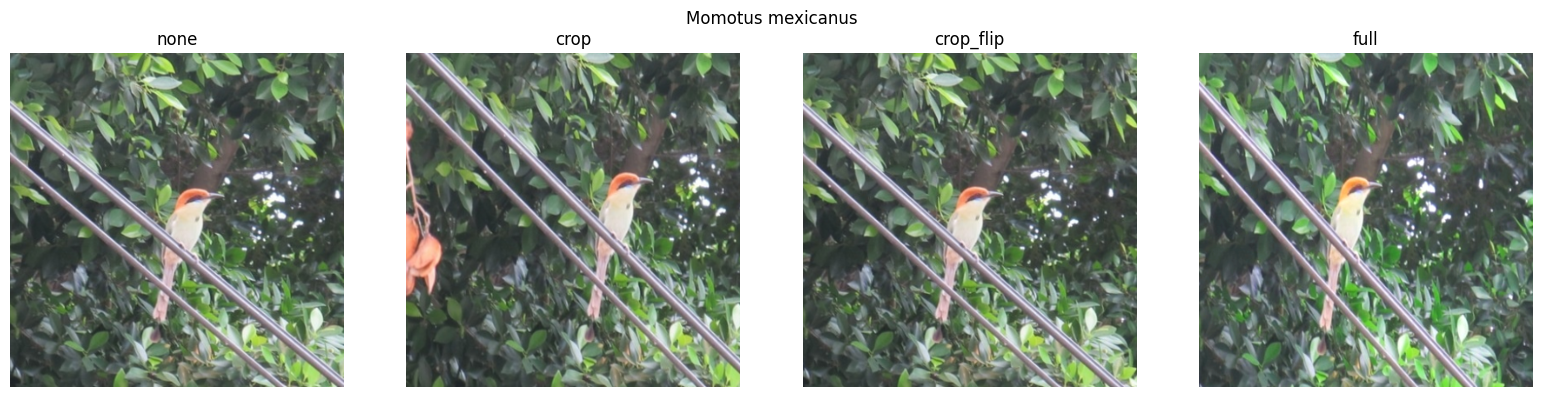

In [11]:
# Function to transform batch examples using the specified transformation
def transform_batch(examples, transform):
    pixel_values = [transform(image.convert("RGB")) for image in examples["image"]]
    return {"pixel_values": pixel_values, "label": examples["label"]}

# Function to collate a batch of examples into tensors
def collate_fn(examples):
    pixel_values = torch.stack([example["pixel_values"] for example in examples])
    labels = torch.tensor([example["label"] for example in examples], dtype=torch.long)
    return {"pixel_values": pixel_values, "labels": labels}

# Function to create transformed datasets for training, validation, and testing
def transformed_datasets(recipe: str):
    train_transform = build_train_transform(recipe)
    train_data = image_datasets["train"].with_transform(partial(transform_batch, transform=train_transform))
    validation_data = image_datasets["validation"].with_transform(
        partial(transform_batch, transform=EVALUATION_TRANSFORM)
    )
    test_data = image_datasets["test"].with_transform(partial(transform_batch, transform=EVALUATION_TRANSFORM))
    return train_data, validation_data, test_data

# Function to display a tensor image with the specified title
def display_tensor_image(tensor, axis, title):
    mean = torch.tensor(IMAGE_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGE_STD).view(3, 1, 1)
    image = (tensor.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0)
    axis.imshow(image)
    axis.set_title(title)
    axis.axis("off")

# Display a sample image with augmentation examples
sample = image_datasets["train"][0]
figure, axes = plt.subplots(1, 4, figsize=(16, 4))

for axis, recipe in zip(axes, ["none", "crop", "crop_flip", "full"]):
    display_tensor_image(build_train_transform(recipe)(sample["image"].convert("RGB")), axis, recipe)

figure.suptitle(scientific_name(CLASS_NAMES[sample["label"]]))
plt.tight_layout()
plt.show()

## EfficientNetV2-S model
For scratch experiments, `weights=None` randomises the entire network. For pretrained experiments, the ImageNet backbone is loaded and the new species classifier is randomly initialised. All layers remain trainable for full fine-tuning.

In [12]:
# Define the EfficientNetV2SClassifier model + Dropout Layer + Linear Layer for classification
class EfficientNetV2SClassifier(nn.Module):
    def __init__(self, num_classes: int, pretrained: bool):
        super().__init__()
        self.config = PretrainedConfig(num_labels=num_classes, problem_type="single_label_classification")
        weights = PRETRAINED_WEIGHTS if pretrained else None
        self.network = efficientnet_v2_s(weights=weights)
        in_features = self.network.classifier[1].in_features
        self.network.classifier[1] = nn.Linear(in_features, num_classes)

    def forward(self, pixel_values, labels=None):
        logits = self.network(pixel_values)
        loss = F.cross_entropy(logits, labels) if labels is not None else None
        return ImageClassifierOutput(loss=loss, logits=logits)

# Function to build the EfficientNetV2SClassifier model
def build_model(pretrained: bool):
    return EfficientNetV2SClassifier(NUM_CLASSES, pretrained)

# Check the number of parameters in the model
model_probe = build_model(pretrained=False)
total_parameters = sum(parameter.numel() for parameter in model_probe.parameters())
trainable_parameters = sum(parameter.numel() for parameter in model_probe.parameters() if parameter.requires_grad)

print(f"Total parameters: {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")
del model_probe
gc.collect()

Total parameters: 21,458,488
Trainable parameters: 21,458,488


9

## Experiment configuration
Hyperparameters
- scratch: learning rate `1e-3`, maximum 50 epochs;
- pretrained: learning rate `5e-5`, maximum 30 epochs.

In [9]:
# Define the experiments with different configurations
EXPERIMENTS = {
    "scratch_no_aug": {"pretrained": False, "augmentation": "none", "learning_rate": 1e-3, "epochs": 50},
    "scratch_full_aug": {"pretrained": False, "augmentation": "full", "learning_rate": 1e-3, "epochs": 50},
    "pretrained_no_aug": {"pretrained": True, "augmentation": "none", "learning_rate": 5e-5, "epochs": 30},
    "pretrained_full_aug": {"pretrained": True, "augmentation": "full", "learning_rate": 5e-5, "epochs": 30},
    "pretrained_crop_flip": {"pretrained": True, "augmentation": "crop_flip", "learning_rate": 5e-5, "epochs": 30},
    "pretrained_crop": {"pretrained": True, "augmentation": "crop", "learning_rate": 5e-5, "epochs": 30},
}

# Set up output directories for each experiment
for name, config in EXPERIMENTS.items():
    config["checkpoint_dir"] = OUTPUT_ROOT / "checkpoints" / name
    config["final_dir"] = OUTPUT_ROOT / "final_models" / name

## Metrics
- Validation using top-1 accuracy, top-5 accuracy, and macro-F1 every epoch. 
- Early stopping and best-checkpoint selection use validation top-1 accuracy.
- Final test evaluation also reports balanced accuracy and macro-averaged precision, recall, and F1. 

In [14]:
# Define evaluation metrics

# Top-k accuracy function
def top_k_accuracy(logits, labels, k=5):
    top_k = np.argpartition(logits, -k, axis=1)[:, -k:]
    return float(np.mean(np.any(top_k == labels[:, None], axis=1)))

# Eval metric computation function
def compute_metrics(eval_prediction):
    logits = eval_prediction.predictions
    labels = eval_prediction.label_ids
    predictions = np.argmax(logits, axis=1)
    return {
        "accuracy": float(accuracy_score(labels, predictions)),
        "top5_accuracy": top_k_accuracy(logits, labels, k=5),
        "macro_f1": float(f1_score(labels, predictions, average="macro", zero_division=0)),
    }

# Eval function
def evaluate_predictions(logits, labels, k=5):
    predictions = np.argmax(logits, axis=1)
    overall_accuracy = float(accuracy_score(labels, predictions))
    return {
        "top1_accuracy": overall_accuracy,
        "top5_accuracy": top_k_accuracy(logits, labels, k),
        "overall_accuracy": overall_accuracy,
        "balanced_accuracy": float(balanced_accuracy_score(labels, predictions)),
        "macro_precision": float(precision_score(labels, predictions, average="macro", zero_division=0)),
        "macro_recall": float(recall_score(labels, predictions, average="macro", zero_division=0)),
        "macro_f1": float(f1_score(labels, predictions, average="macro", zero_division=0)),
    }

In [15]:
# Hugging Face Trainer Arguments for Training and Prediction
def training_arguments(name: str, config: dict):
    return TrainingArguments(
        output_dir=str(config["checkpoint_dir"]),
        run_name=name,
        num_train_epochs=config["epochs"],
        learning_rate=config["learning_rate"],
        lr_scheduler_type="cosine",
        warmup_steps=WARMUP_STEPS,
        weight_decay=WEIGHT_DECAY,
        label_smoothing_factor=LABEL_SMOOTHING_FACTOR,
        optim="adamw_torch",
        max_grad_norm=1.0,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=10,
        logging_first_step=True,
        load_best_model_at_end=True,
        metric_for_best_model="accuracy",
        greater_is_better=True,
        save_total_limit=SAVE_TOTAL_LIMIT,
        fp16=DEVICE.type == "cuda",
        use_cpu=DEVICE.type == "cpu",
        eval_accumulation_steps=4,
        dataloader_num_workers=NUM_WORKERS,
        dataloader_pin_memory=DEVICE.type == "cuda",
        dataloader_persistent_workers=NUM_WORKERS > 0,
        remove_unused_columns=False,
        label_names=["labels"],
        seed=RANDOM_SEED,
        data_seed=RANDOM_SEED,
        restore_callback_states_from_checkpoint=True,
        report_to="none",
    )

# Hugging Face Trainer Arguments for Prediction
def prediction_arguments(name: str, final_dir: Path):
    return TrainingArguments(
        output_dir=str(final_dir),
        run_name=f"{name}_test",
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        fp16=DEVICE.type == "cuda",
        use_cpu=DEVICE.type == "cpu",
        eval_accumulation_steps=4,
        dataloader_num_workers=NUM_WORKERS,
        dataloader_pin_memory=DEVICE.type == "cuda",
        dataloader_persistent_workers=NUM_WORKERS > 0,
        remove_unused_columns=False,
        label_names=["labels"],
        seed=RANDOM_SEED,
        data_seed=RANDOM_SEED,
        report_to="none",
    )

In [16]:
# Utility Functions

# Function to find the latest checkpoint in a directory
def latest_checkpoint(checkpoint_dir: Path):
    checkpoints = list(checkpoint_dir.glob("checkpoint-*"))
    return str(max(checkpoints, key=lambda path: int(path.name.split("-")[-1]))) if checkpoints else None

# Function to save data as a JSON file
def save_json(data, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as file:
        json.dump(data, file, indent=2)

# Function to plot training history and save it as a CSV and PNG file
def plot_training_history(log_history, name: str, final_dir: Path):
    history = pd.DataFrame(log_history)
    history.to_csv(final_dir / "trainer_history.csv", index=False)

    train_rows = history.dropna(subset=["loss"]) if "loss" in history else pd.DataFrame()
    validation_rows = history.dropna(subset=["eval_loss"]) if "eval_loss" in history else pd.DataFrame()

    # Plot training and validation loss
    figure, axes = plt.subplots(1, 2, figsize=(14, 5))
    if not train_rows.empty:
        axes[0].plot(train_rows["epoch"], train_rows["loss"], label="training loss")
    if not validation_rows.empty:
        axes[0].plot(validation_rows["epoch"], validation_rows["eval_loss"], marker="o", label="validation loss")
    axes[0].set(xlabel="Epoch", ylabel="Loss", title=f"{name}: loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Plot validation metrics if available
    if not validation_rows.empty:
        axes[1].plot(validation_rows["epoch"], validation_rows["eval_accuracy"], marker="o", label="top-1 accuracy")
        axes[1].plot(validation_rows["epoch"], validation_rows["eval_top5_accuracy"], marker="s", label="top-5 accuracy")
        axes[1].plot(validation_rows["epoch"], validation_rows["eval_macro_f1"], marker="^", label="macro-F1")
    axes[1].set(xlabel="Epoch", ylabel="Score", title=f"{name}: validation metrics")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(final_dir / "training_curves.png", dpi=200, bbox_inches="tight")
    plt.show()

In [17]:
# Run Experiment Function
def run_experiment(name: str, config: dict, resume=True):
    checkpoint_dir = config["checkpoint_dir"]
    final_dir = config["final_dir"]
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    final_dir.mkdir(parents=True, exist_ok=True)

    set_global_seed(RANDOM_SEED)
    train_data, validation_data, _ = transformed_datasets(config["augmentation"])
    model = build_model(config["pretrained"])
    arguments = training_arguments(name, config)
    trainer = Trainer(
        model=model,
        args=arguments,
        train_dataset=train_data,
        eval_dataset=validation_data,
        data_collator=collate_fn,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(
            early_stopping_patience=EARLY_STOPPING_PATIENCE,
            early_stopping_threshold=EARLY_STOPPING_THRESHOLD,
        )],
    )

    checkpoint = latest_checkpoint(checkpoint_dir) if resume else None
    
    # Print experiment details
    print(f"Experiment: {name}")
    print(f"Initialisation: {'ImageNet-1K' if config['pretrained'] else 'random'}")
    print(f"Augmentation: {config['augmentation']}")
    print(f"Resume checkpoint: {checkpoint}")

    start_time = time.perf_counter()
    train_result = trainer.train(resume_from_checkpoint=checkpoint)
    wall_time = time.perf_counter() - start_time

    trainer.save_model(str(final_dir))
    plot_training_history(trainer.state.log_history, name, final_dir)

    metadata = {
        "experiment": name,
        "architecture": "EfficientNetV2-S",
        "pretrained": config["pretrained"],
        "pretrained_source": "TorchVision EfficientNet_V2_S_Weights.DEFAULT (ImageNet-1K)" if config["pretrained"] else None,
        "augmentation": config["augmentation"],
        "num_classes": NUM_CLASSES,
        "train_images": len(image_datasets["train"]),
        "validation_images": len(image_datasets["validation"]),
        "image_size": IMAGE_SIZE,
        "random_seed": RANDOM_SEED,
        "learning_rate": config["learning_rate"],
        "maximum_epochs": config["epochs"],
        "physical_batch_size": TRAIN_BATCH_SIZE,
        "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
        "effective_batch_size": TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS,
        "best_checkpoint": trainer.state.best_model_checkpoint,
        "best_validation_metric": trainer.state.best_metric,
        "training_runtime_this_call_seconds": wall_time,
        "device": DEVICE_NAME,
        "torch_version": torch.__version__,
        "torchvision_version": torchvision.__version__,
        "transformers_version": transformers.__version__,
    }
    
    train_metrics = {
      "train_runtime": float(train_result.metrics["train_runtime"]),
      "epoch": float(train_result.metrics["epoch"]),
    }
    
    save_json(metadata, final_dir / "metadata.json")
    save_json(train_metrics, final_dir / "train_metrics.json")

    del trainer, model, train_data, validation_data
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return {**metadata, **train_metrics}

# Model training
Existing checkpoints are resumed when `RESUME_TRAINING = True`. 

## a. pretrained model, without data augmentation

Experiment: pretrained_no_aug
Initialisation: ImageNet-1K
Augmentation: none
Resume checkpoint: None


Epoch,Training Loss,Validation Loss,Accuracy,Top5 Accuracy,Macro F1
1,6.859209,nan,0.004200,0.018700,0.003357
2,6.206234,nan,0.101700,0.273200,0.069328
3,4.882766,nan,0.232700,0.540400,0.176664
4,3.844485,nan,0.389100,0.717800,0.341652
5,3.256332,3.035001,0.511300,0.804900,0.482198
6,2.744548,2.677296,0.588200,0.850200,0.565342
7,2.485940,2.445487,0.638000,0.874000,0.622505
8,2.167812,2.294091,0.672300,0.892400,0.661053
9,1.967212,2.188100,0.696300,0.898700,0.689733
10,1.796999,2.113806,0.717900,0.904500,0.711902


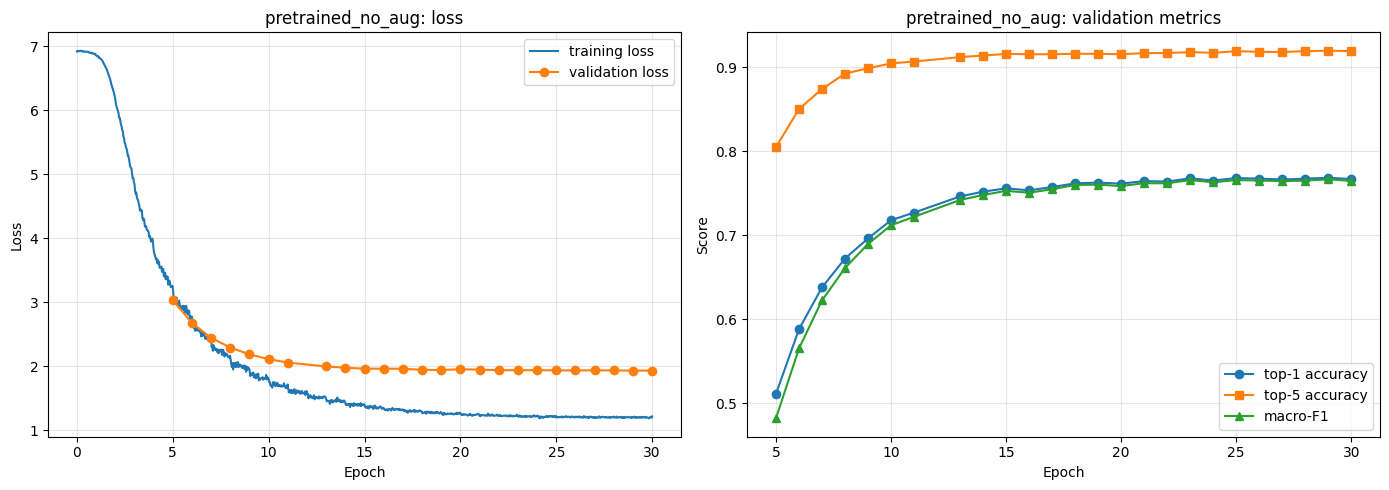

experiment                                                            pretrained_no_aug
architecture                                                           EfficientNetV2-S
pretrained                                                                         True
pretrained_source                     TorchVision EfficientNet_V2_S_Weights.DEFAULT ...
augmentation                                                                       none
num_classes                                                                        1000
train_images                                                                      40000
validation_images                                                                 10000
image_size                                                                          384
random_seed                                                                    20269517
learning_rate                                                                   0.00005
maximum_epochs                  

In [20]:
experiment_name = "pretrained_no_aug"
training_summary = run_experiment(experiment_name, EXPERIMENTS[experiment_name], resume=RESUME_TRAINING)
pd.Series(training_summary)

## b. pre-trained model, with full data augmentation

Experiment: pretrained_full_aug
Initialisation: ImageNet-1K
Augmentation: full
Resume checkpoint: None


Epoch,Training Loss,Validation Loss,Accuracy,Top5 Accuracy,Macro F1
1,6.862746,nan,0.003800,0.018100,0.003130
2,6.217073,nan,0.096900,0.267400,0.066147
3,4.923747,nan,0.225300,0.527200,0.169702
4,3.909637,nan,0.374300,0.707400,0.324968
5,3.360424,3.079732,0.495900,0.798500,0.464148
6,2.865088,2.725481,0.573300,0.844300,0.548694
7,2.648701,2.476451,0.631500,0.870300,0.615131
8,2.347415,2.336030,0.666700,0.888800,0.654668
9,2.132625,2.202502,0.693600,0.901200,0.685119
10,1.974584,2.158100,0.715000,0.906400,0.707267


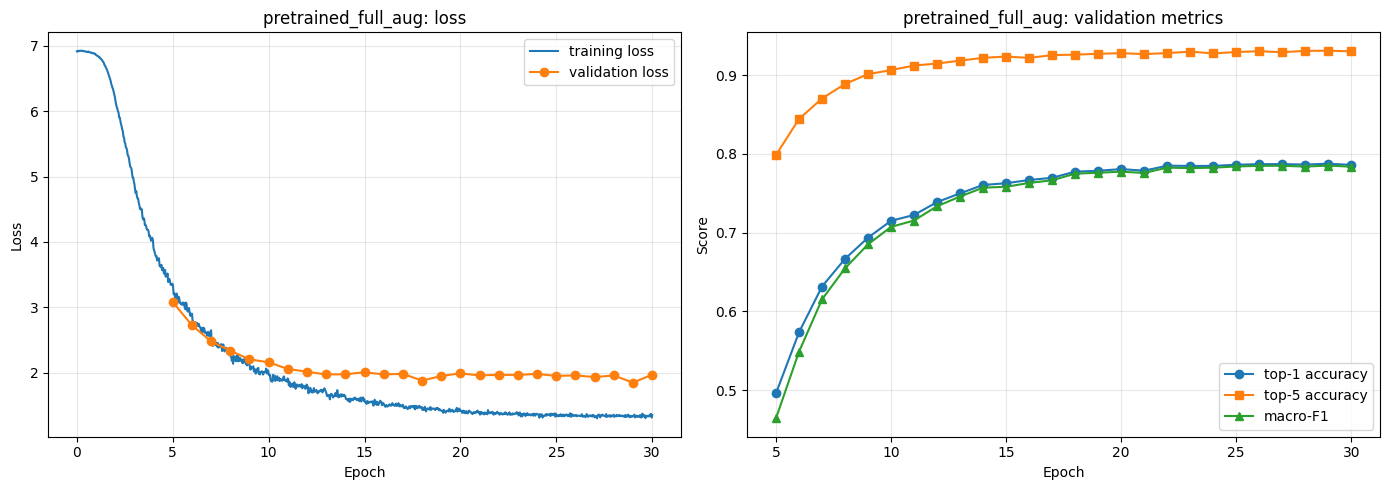

experiment                                                          pretrained_full_aug
architecture                                                           EfficientNetV2-S
pretrained                                                                         True
pretrained_source                     TorchVision EfficientNet_V2_S_Weights.DEFAULT ...
augmentation                                                                       full
num_classes                                                                        1000
train_images                                                                      40000
validation_images                                                                 10000
image_size                                                                          384
random_seed                                                                    20269517
learning_rate                                                                   0.00005
maximum_epochs                  

In [21]:
experiment_name = "pretrained_full_aug"
training_summary = run_experiment(experiment_name, EXPERIMENTS[experiment_name], resume=RESUME_TRAINING)
pd.Series(training_summary)

## c. from-scratch model, without data augmentation

Experiment: scratch_no_aug
Initialisation: random
Augmentation: none
Resume checkpoint: None


Epoch,Training Loss,Validation Loss,Accuracy,Top5 Accuracy,Macro F1
1,6.624920,6.781767,0.006100,0.025000,0.000343
2,6.415958,6.289463,0.012900,0.049500,0.003234
3,6.148598,6.067815,0.022700,0.082100,0.009060
4,5.938538,5.823932,0.036700,0.128900,0.022654
5,5.721667,5.568285,0.059600,0.185300,0.038954
6,5.519365,5.405717,0.078200,0.224300,0.055895
7,5.325335,5.199122,0.107400,0.274600,0.080762
8,5.120283,5.045228,0.123700,0.310100,0.096690
9,4.952938,4.854934,0.155200,0.358500,0.131822
10,4.745689,4.753670,0.170100,0.385100,0.147149


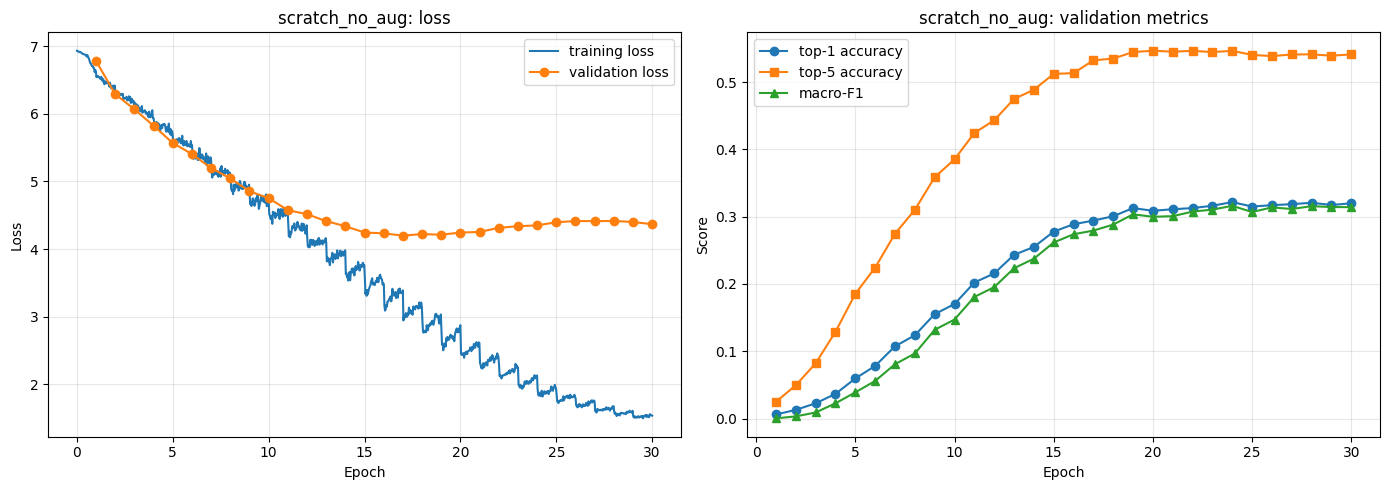

experiment                                                               scratch_no_aug
architecture                                                           EfficientNetV2-S
pretrained                                                                        False
pretrained_source                                                                  None
augmentation                                                                       none
num_classes                                                                        1000
train_images                                                                      40000
validation_images                                                                 10000
image_size                                                                          384
random_seed                                                                    20269517
learning_rate                                                                     0.001
maximum_epochs                  

In [22]:
experiment_name = "scratch_no_aug"
training_summary = run_experiment(experiment_name, EXPERIMENTS[experiment_name], resume=RESUME_TRAINING)
pd.Series(training_summary)

## d. from-scratch model, with full data augmentation

Experiment: scratch_full_aug
Initialisation: random
Augmentation: full
Resume checkpoint: None


Epoch,Training Loss,Validation Loss,Accuracy,Top5 Accuracy,Macro F1
1,6.677087,7.159314,0.005200,0.023500,0.000316
2,6.461484,6.291897,0.011500,0.047300,0.002267
3,6.230508,6.100836,0.021000,0.081500,0.009494
4,6.013607,5.860792,0.036000,0.124500,0.020497
5,5.844637,5.644442,0.057100,0.170400,0.037421
6,5.632386,5.450652,0.075100,0.216100,0.053216
7,5.483298,5.273760,0.093600,0.256300,0.068472
8,5.299569,5.133076,0.111200,0.288100,0.082491
9,5.155107,4.919809,0.141700,0.337800,0.114891
10,4.952420,4.749687,0.171200,0.388000,0.145241


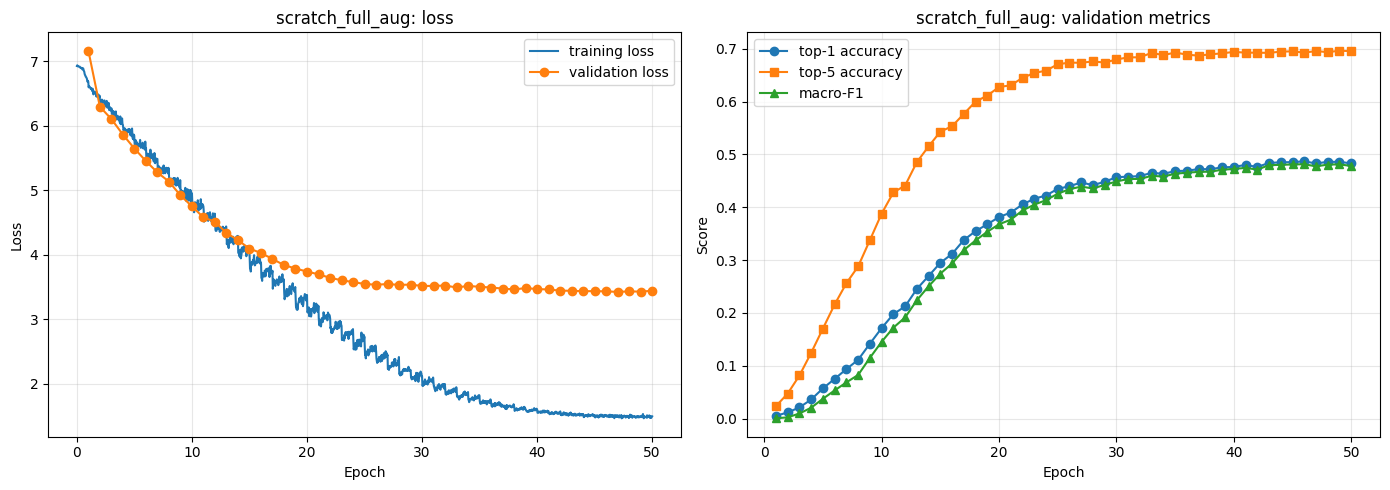

experiment                                                             scratch_full_aug
architecture                                                           EfficientNetV2-S
pretrained                                                                        False
pretrained_source                                                                  None
augmentation                                                                       full
num_classes                                                                        1000
train_images                                                                      40000
validation_images                                                                 10000
image_size                                                                          384
random_seed                                                                    20269517
learning_rate                                                                     0.001
maximum_epochs                  

In [23]:
experiment_name = "scratch_full_aug"
training_summary = run_experiment(experiment_name, EXPERIMENTS[experiment_name], resume=RESUME_TRAINING)
pd.Series(training_summary)

## e. pre-trained model, with random crop and horizontal flip

Experiment: pretrained_crop_flip
Initialisation: ImageNet-1K
Augmentation: crop_flip
Resume checkpoint: None


Epoch,Training Loss,Validation Loss,Accuracy,Top5 Accuracy,Macro F1
1,6.855493,nan,0.003800,0.018800,0.002903
2,6.215221,nan,0.102300,0.272200,0.070413
3,4.896212,nan,0.229800,0.534300,0.175229
4,3.863983,nan,0.381000,0.714100,0.331665
5,3.318450,3.174190,0.508100,0.807000,0.478621
6,2.809257,2.695580,0.584500,0.850900,0.561059
7,2.590232,2.442497,0.640700,0.874100,0.625024
8,2.289424,2.292301,0.669400,0.892000,0.658030
9,2.104293,2.183662,0.699800,0.896900,0.692131
10,1.963822,2.096423,0.718400,0.906900,0.711397


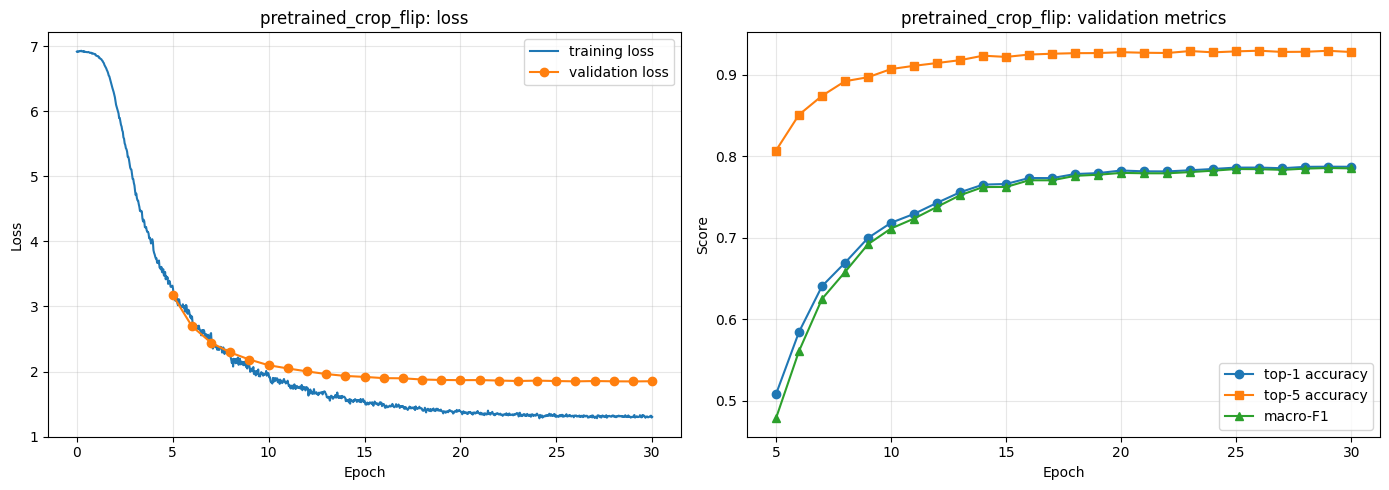

experiment                                                         pretrained_crop_flip
architecture                                                           EfficientNetV2-S
pretrained                                                                         True
pretrained_source                     TorchVision EfficientNet_V2_S_Weights.DEFAULT ...
augmentation                                                                  crop_flip
num_classes                                                                        1000
train_images                                                                      40000
validation_images                                                                 10000
image_size                                                                          384
random_seed                                                                    20269517
learning_rate                                                                   0.00005
maximum_epochs                  

In [24]:
experiment_name = "pretrained_crop_flip"
training_summary = run_experiment(experiment_name, EXPERIMENTS[experiment_name], resume=RESUME_TRAINING)
pd.Series(training_summary)

## f. pre-trained model, with random crop only

Experiment: pretrained_crop
Initialisation: ImageNet-1K
Augmentation: crop
Resume checkpoint: None


Epoch,Training Loss,Validation Loss,Accuracy,Top5 Accuracy,Macro F1
1,6.857384,nan,0.003600,0.018300,0.002750
2,6.213205,nan,0.101700,0.270700,0.070047
3,4.904181,nan,0.227400,0.536600,0.172625
4,3.865852,nan,0.387500,0.719500,0.338125
5,3.292862,3.051314,0.504400,0.799800,0.473242
6,2.793251,2.694537,0.583300,0.848800,0.560822
7,2.559694,2.449108,0.638000,0.872400,0.622357
8,2.273837,2.300220,0.666000,0.891100,0.654155
9,2.061575,2.194178,0.697500,0.899000,0.689763
10,1.903376,2.112085,0.717200,0.905600,0.710716


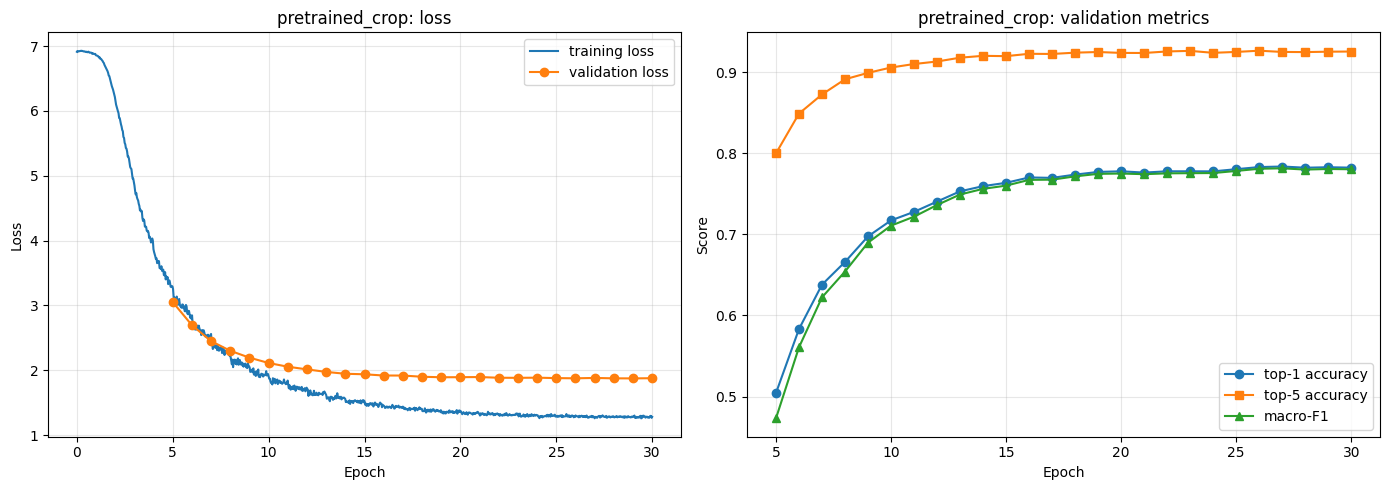

experiment                                                              pretrained_crop
architecture                                                           EfficientNetV2-S
pretrained                                                                         True
pretrained_source                     TorchVision EfficientNet_V2_S_Weights.DEFAULT ...
augmentation                                                                       crop
num_classes                                                                        1000
train_images                                                                      40000
validation_images                                                                 10000
image_size                                                                          384
random_seed                                                                    20269517
learning_rate                                                                   0.00005
maximum_epochs                  

In [25]:
experiment_name = "pretrained_crop"
training_summary = run_experiment(experiment_name, EXPERIMENTS[experiment_name], resume=RESUME_TRAINING)
pd.Series(training_summary)

## Final test evaluation
- The full 1,000 × 1,000 confusion matrix is saved numerically and as a log-scaled overview. 
- A readable 20-class confusion matrix produced for the classes with the lowest test recall.

In [16]:
# Load a trained model from the final directory of the experiment
def load_trained_model(name: str):
    final_dir = EXPERIMENTS[name]["final_dir"]
    model = build_model(pretrained=False)
    state_dict = load_file(
        str(final_dir / "model.safetensors"),
        device="cpu",
    )
    model.load_state_dict(state_dict)
    return model.to(DEVICE).eval()


# Function to save confusion matrices
def save_confusion_analysis(
    labels,
    predictions,
    name: str,
    test_result_dir: Path,
):
    matrix = confusion_matrix(
        labels,
        predictions,
        labels=np.arange(NUM_CLASSES),
    )

    plt.figure(figsize=(12, 10))
    plt.imshow(np.log1p(matrix), cmap="magma", aspect="auto")
    plt.title(f"{name}: all-class confusion matrix, log(1 + count)")
    plt.xlabel("Predicted class index")
    plt.ylabel("True class index")
    plt.colorbar(label="log(1 + count)")
    plt.tight_layout()
    plt.savefig(
        test_result_dir / "confusion_matrix_all_classes.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()

    # Calculate recall for each class
    class_totals = matrix.sum(axis=1)
    recall = np.divide(
        np.diag(matrix),
        class_totals,
        out=np.zeros(NUM_CLASSES, dtype=float),
        where=class_totals != 0,
    )

    lowest_recall = np.argsort(recall)[:20]
    selected_matrix = matrix[np.ix_(lowest_recall, lowest_recall)]
    selected_names = [
        scientific_name(CLASS_NAMES[index])
        for index in lowest_recall
    ]

    display = ConfusionMatrixDisplay(
        selected_matrix,
        display_labels=selected_names,
    )
    figure, axis = plt.subplots(figsize=(16, 14))
    display.plot(
        ax=axis,
        xticks_rotation=90,
        colorbar=False,
        values_format="d",
    )
    axis.set_title(f"{name}: 20 classes with lowest recall")
    plt.tight_layout()
    plt.savefig(
        test_result_dir / "confusion_matrix_lowest_recall_20.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()

In [17]:
# Function to evaluate a trained model on the test dataset
def evaluate_experiment(name: str):
    config = EXPERIMENTS[name]
    final_dir = config["final_dir"]
    test_result_dir = final_dir / "test_result"
    test_result_dir.mkdir(parents=True, exist_ok=True)
    model = load_trained_model(name)
    _, _, test_data = transformed_datasets(config["augmentation"])
    trainer = Trainer(
        model=model,
        args=prediction_arguments(name, final_dir),
        data_collator=collate_fn,
        compute_metrics=compute_metrics,
    )

    prediction_output = trainer.predict(test_data, metric_key_prefix="test")
    logits = prediction_output.predictions
    labels = prediction_output.label_ids
    predictions = np.argmax(logits, axis=1)
    metrics = evaluate_predictions(logits, labels, k=5)
    metrics.update({
        "experiment": name,
        "initialisation": "ImageNet-1K" if config["pretrained"] else "random",
        "augmentation": config["augmentation"],
        "test_images": len(labels),
        "test_loss": float(prediction_output.metrics["test_loss"]),
        "test_runtime_seconds": float(prediction_output.metrics["test_runtime"]),
        "test_samples_per_second": float(prediction_output.metrics["test_samples_per_second"]),
    })

    species_ids = class_table["species_id"].to_numpy()
    pd.DataFrame({
        "index": np.arange(len(labels)),
        "prediction_species_id": species_ids[predictions],
        "true_species_id": species_ids[labels],
    }).to_csv(test_result_dir / "test_prediction.csv", index=False)
    pd.DataFrame([metrics]).to_csv(test_result_dir / "test_metrics.csv", index=False)
    save_confusion_analysis(labels, predictions, name, test_result_dir)

    del trainer, model, test_data, prediction_output, logits
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return metrics

### a. Evaluate the pretrained model, without data augmentation

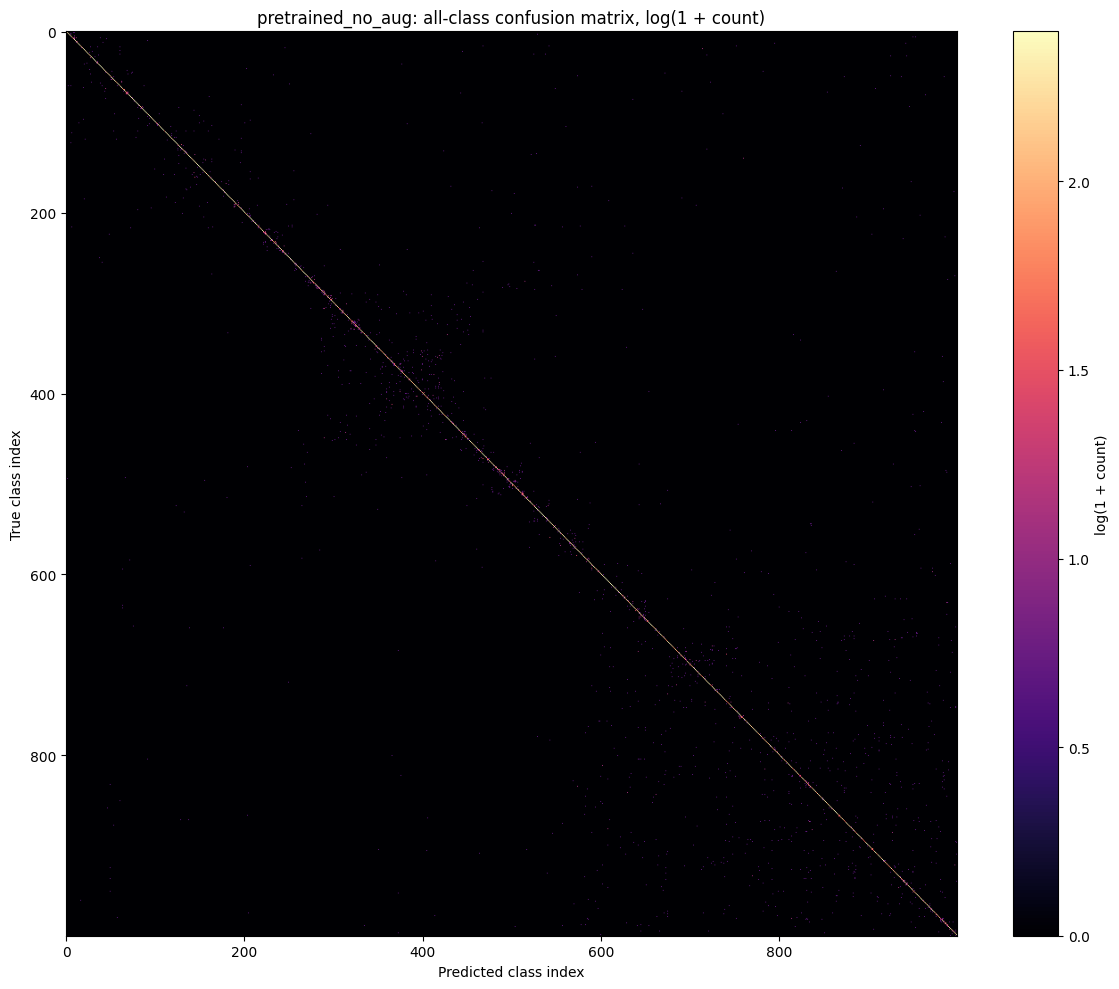

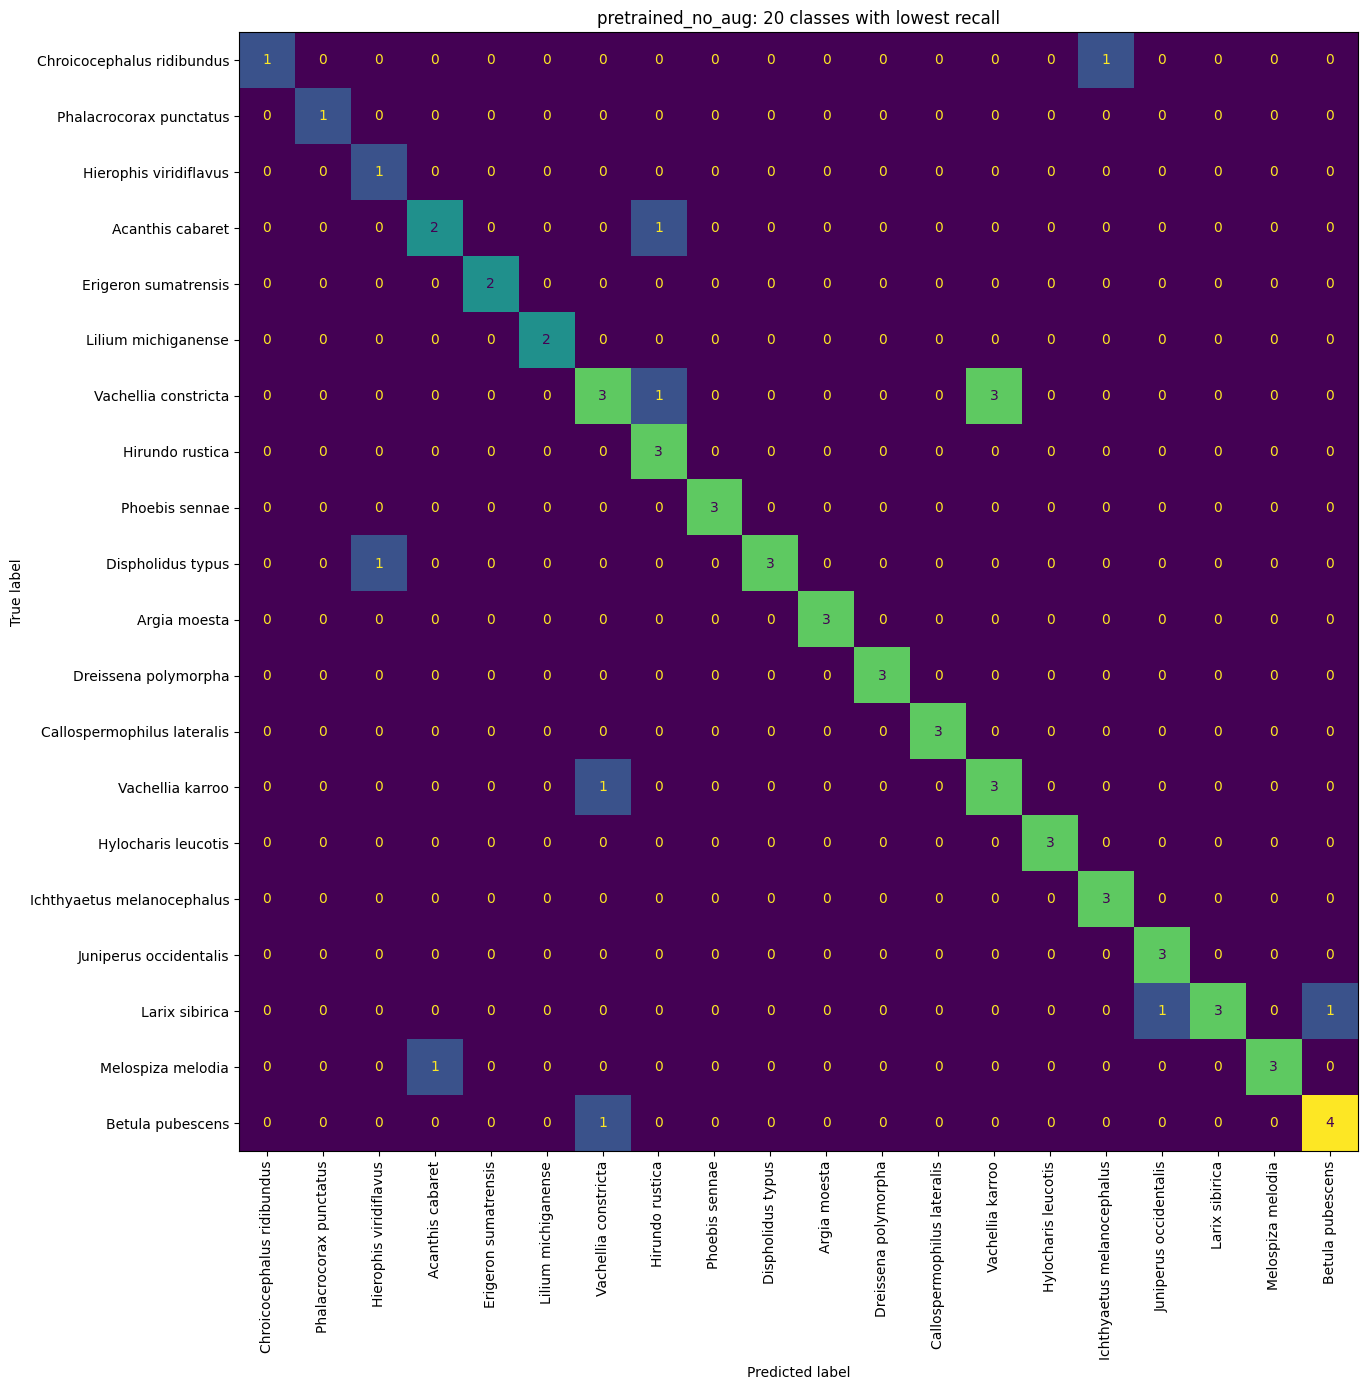

top1_accuracy                         0.7763
top5_accuracy                         0.9226
overall_accuracy                      0.7763
balanced_accuracy                     0.7763
macro_precision                     0.790887
macro_recall                          0.7763
macro_f1                            0.774165
experiment                 pretrained_no_aug
initialisation                   ImageNet-1K
augmentation                            none
test_images                            10000
test_loss                            1.05917
test_runtime_seconds                121.9106
test_samples_per_second               82.027
dtype: object

In [18]:
experiment_name = "pretrained_no_aug"
test_metrics = evaluate_experiment(experiment_name)
pd.Series(test_metrics)

### b. Evaluate the pre-trained model, with full data augmentation

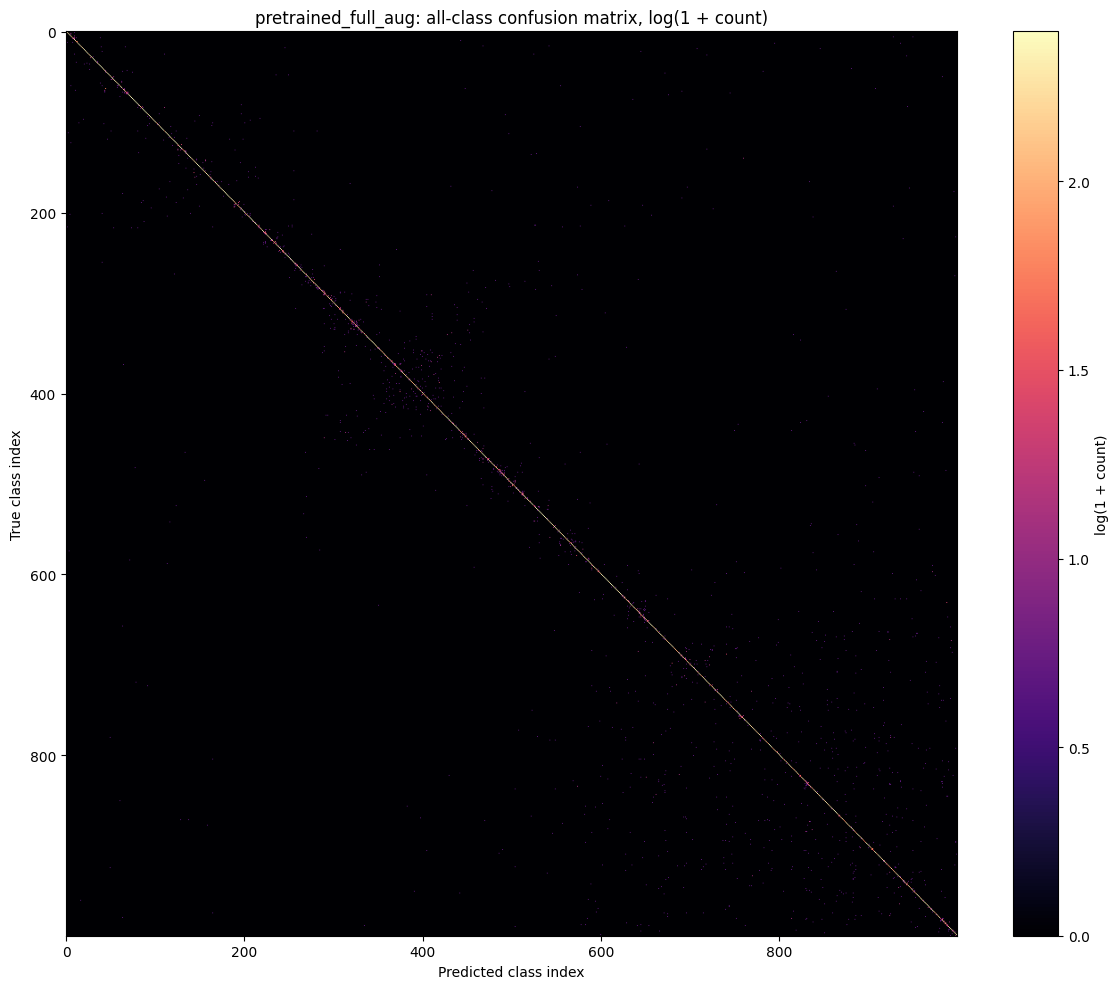

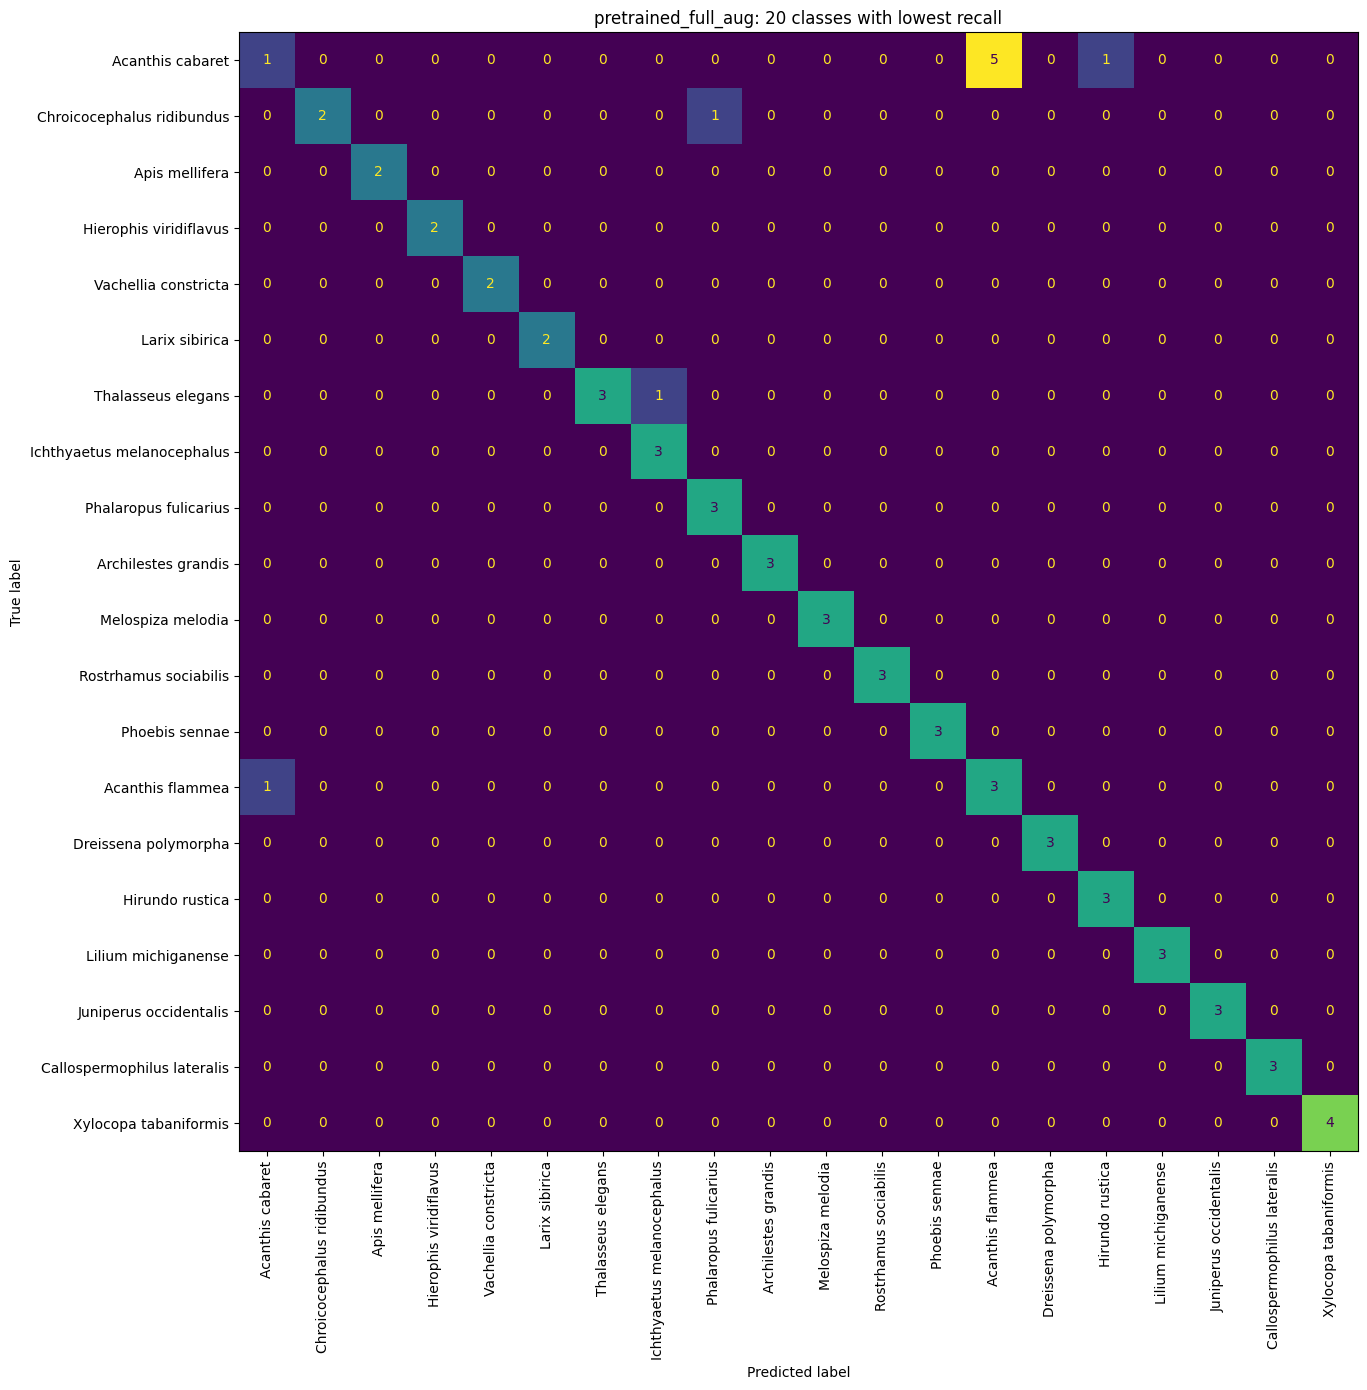

top1_accuracy                           0.7917
top5_accuracy                           0.9325
overall_accuracy                        0.7917
balanced_accuracy                       0.7917
macro_precision                       0.807553
macro_recall                            0.7917
macro_f1                              0.790291
experiment                 pretrained_full_aug
initialisation                     ImageNet-1K
augmentation                              full
test_images                              10000
test_loss                             0.958013
test_runtime_seconds                   54.9983
test_samples_per_second                181.824
dtype: object

In [19]:
experiment_name = "pretrained_full_aug"
test_metrics = evaluate_experiment(experiment_name)
pd.Series(test_metrics)

### c. Evaluate the from-scratch model, without data augmentation

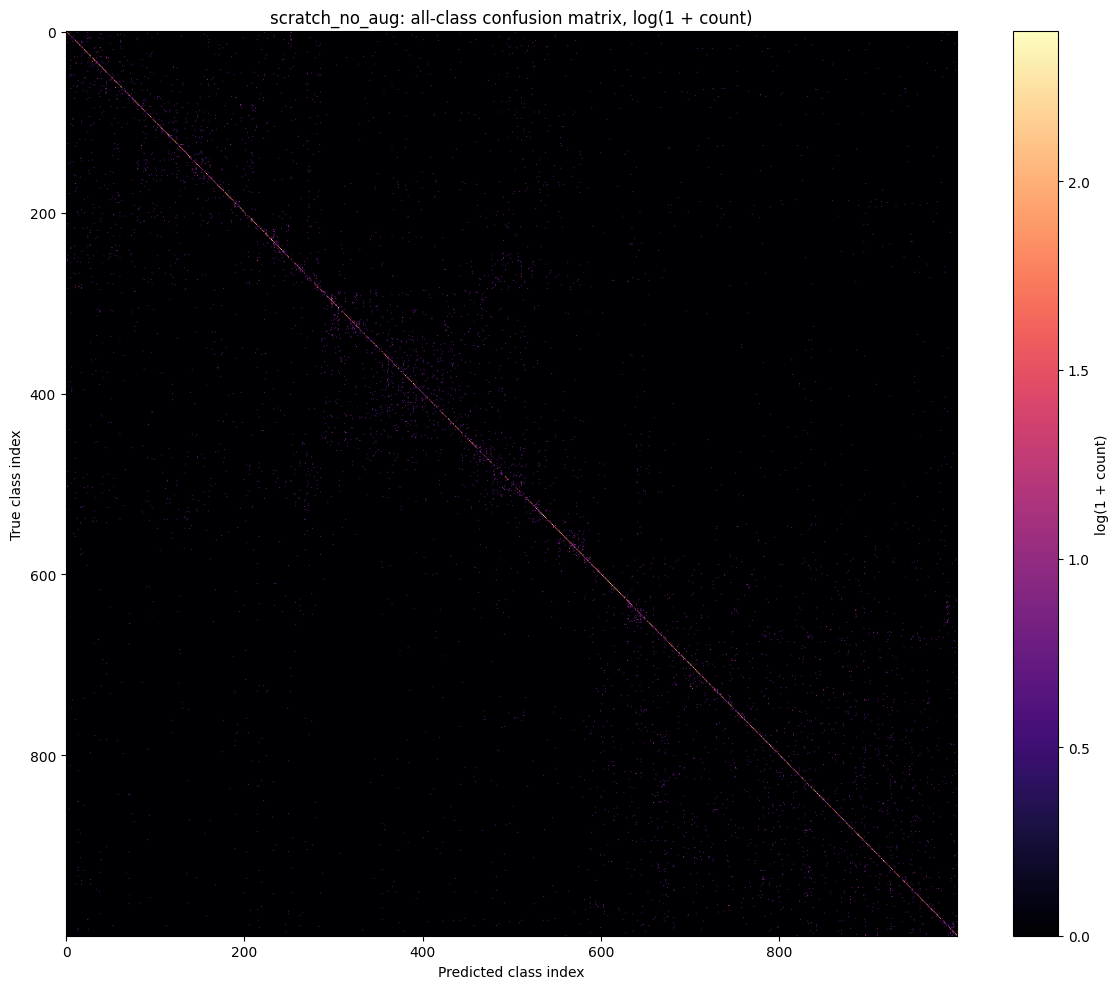

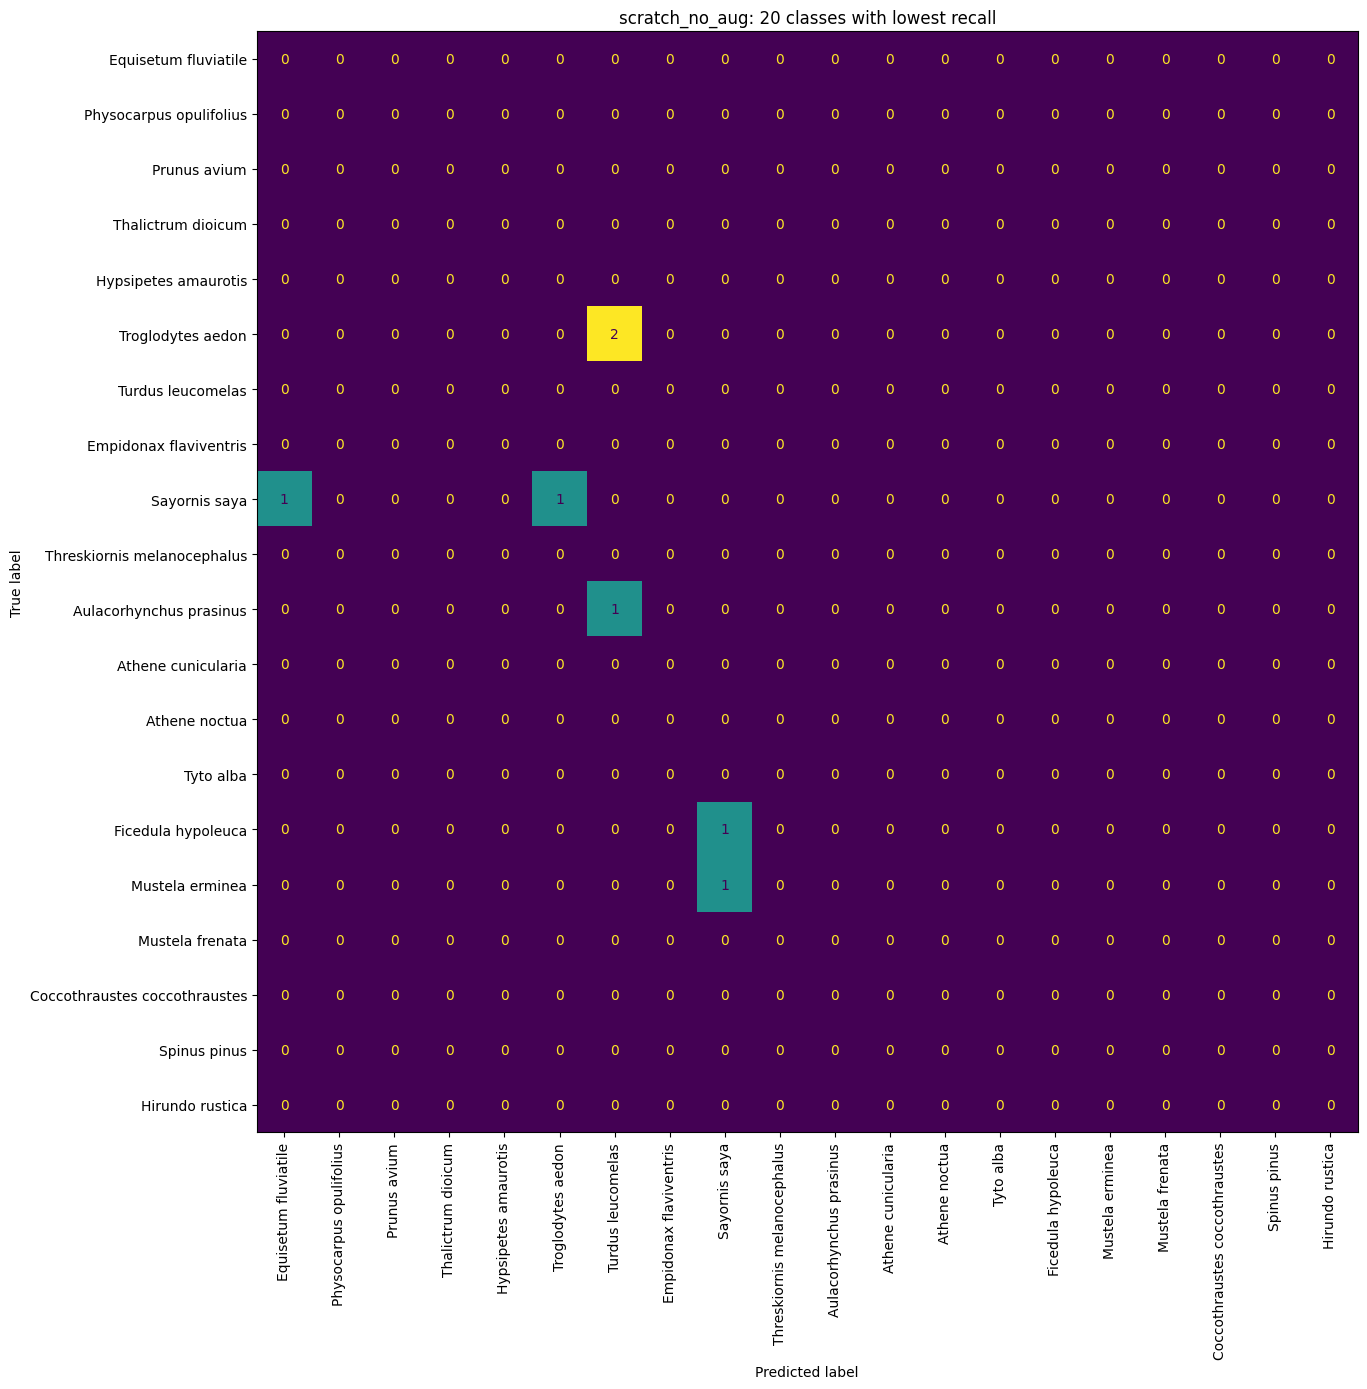

top1_accuracy                      0.3188
top5_accuracy                      0.5492
overall_accuracy                   0.3188
balanced_accuracy                  0.3188
macro_precision                  0.347434
macro_recall                       0.3188
macro_f1                         0.315597
experiment                 scratch_no_aug
initialisation                     random
augmentation                         none
test_images                         10000
test_loss                        3.554922
test_runtime_seconds              53.5421
test_samples_per_second           186.769
dtype: object

In [20]:
experiment_name = "scratch_no_aug"
test_metrics = evaluate_experiment(experiment_name)
pd.Series(test_metrics)

### d. Evaluate the from-scratch model, with full data augmentation

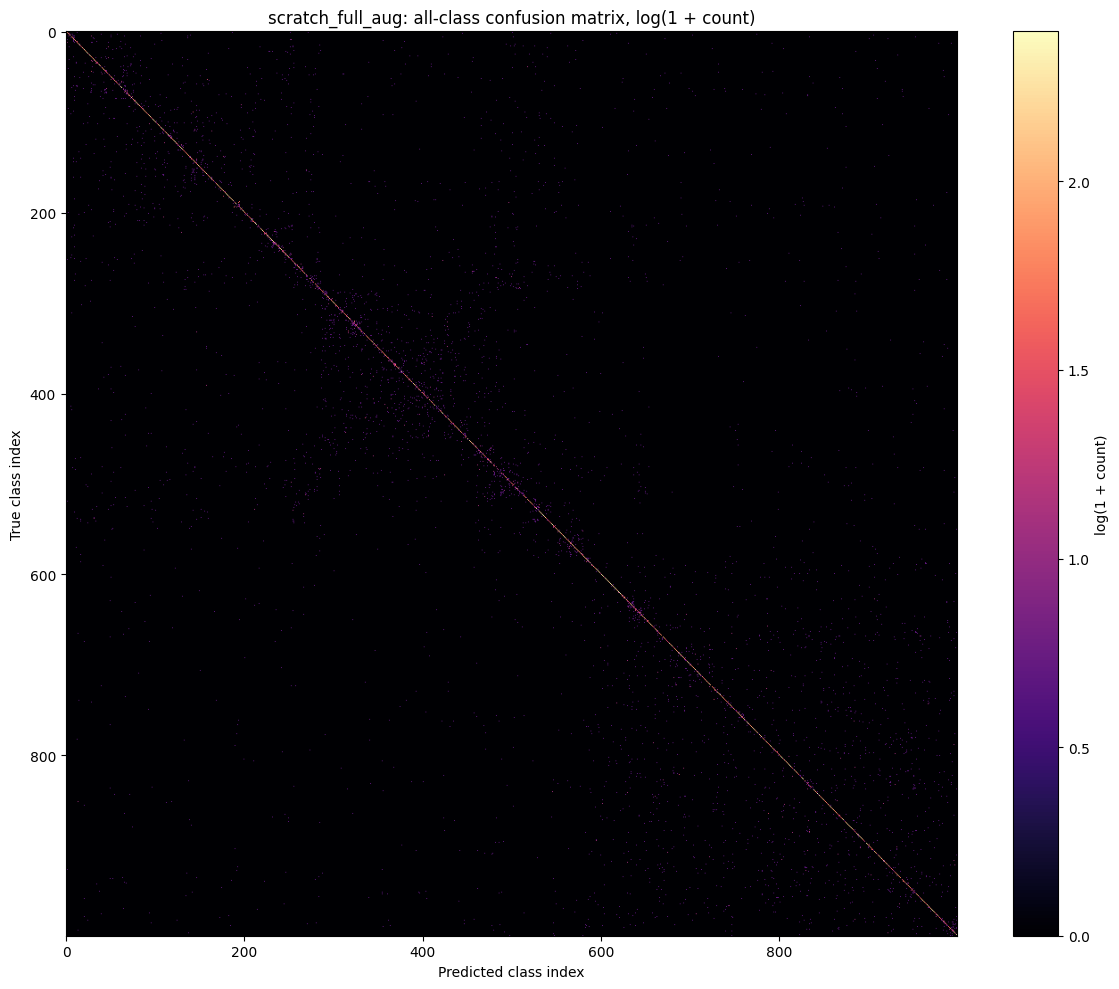

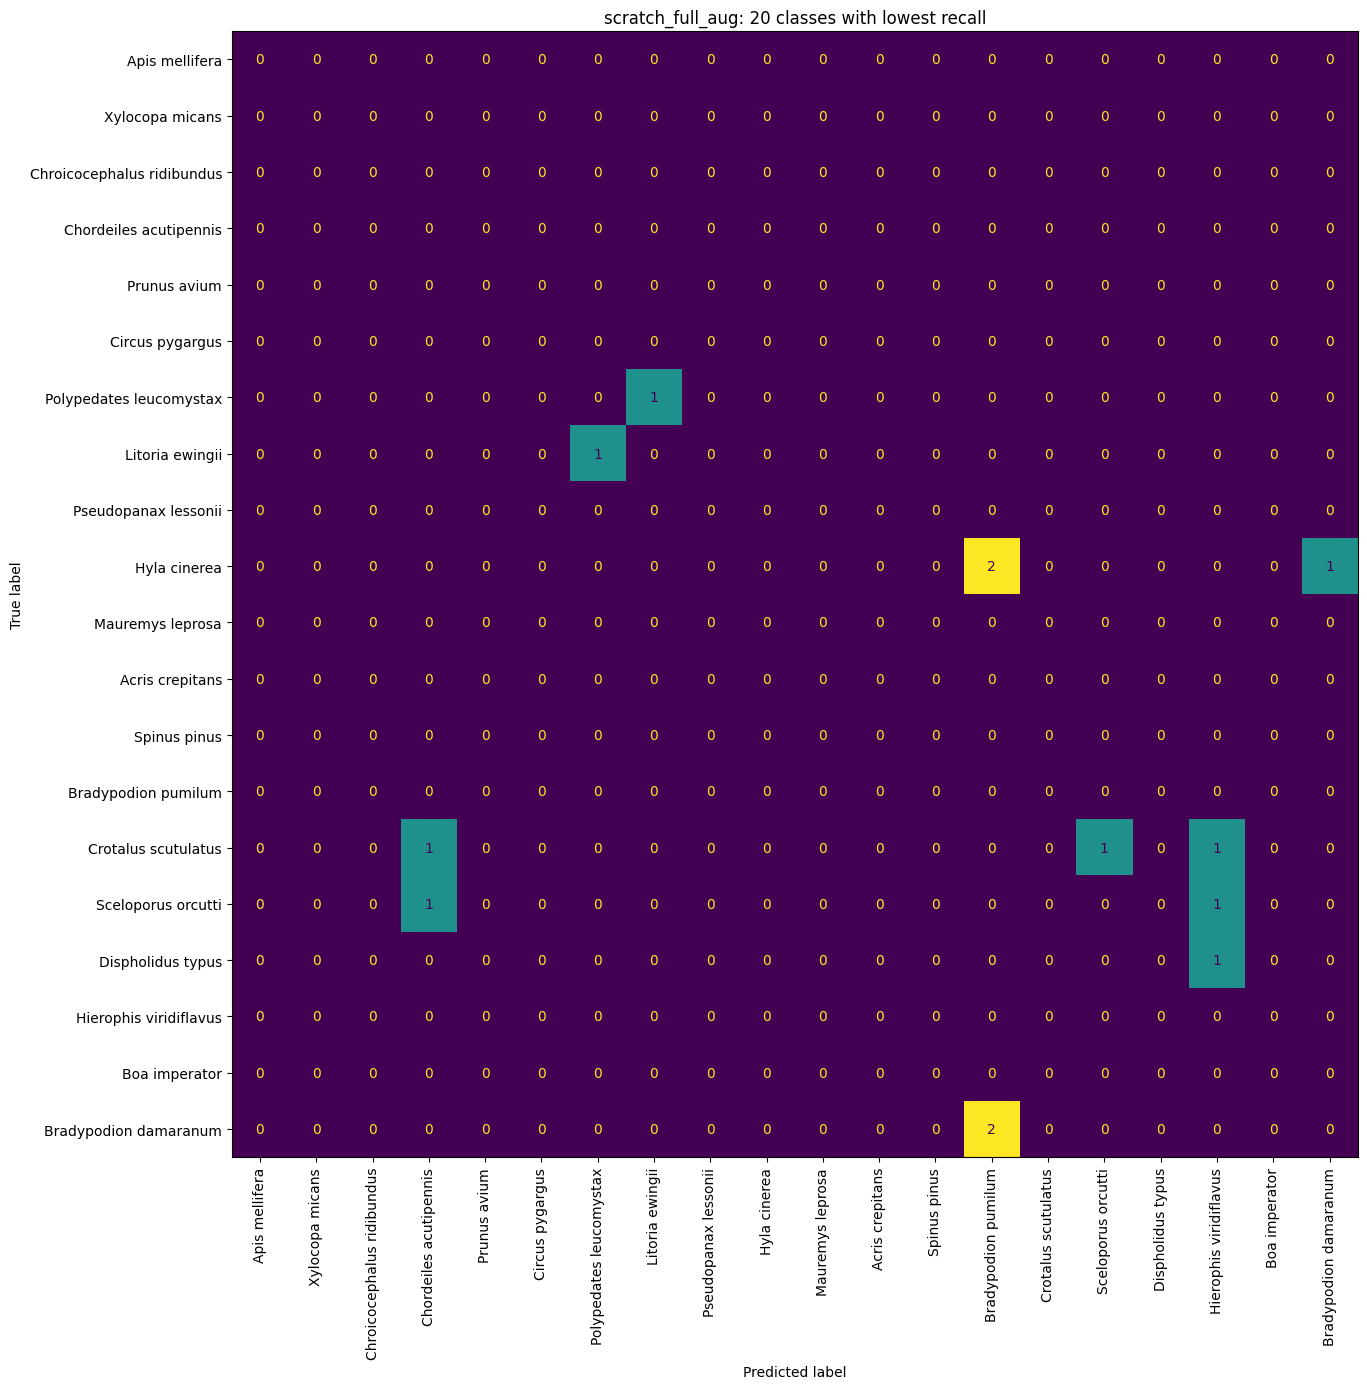

top1_accuracy                        0.4852
top5_accuracy                        0.7055
overall_accuracy                     0.4852
balanced_accuracy                    0.4852
macro_precision                    0.499816
macro_recall                         0.4852
macro_f1                           0.480685
experiment                 scratch_full_aug
initialisation                       random
augmentation                           full
test_images                           10000
test_loss                          2.581155
test_runtime_seconds                53.6942
test_samples_per_second              186.24
dtype: object

In [21]:
experiment_name = "scratch_full_aug"
test_metrics = evaluate_experiment(experiment_name)
pd.Series(test_metrics)

### e. Evaluate the pre-trained model, with random crop and horizontal flip

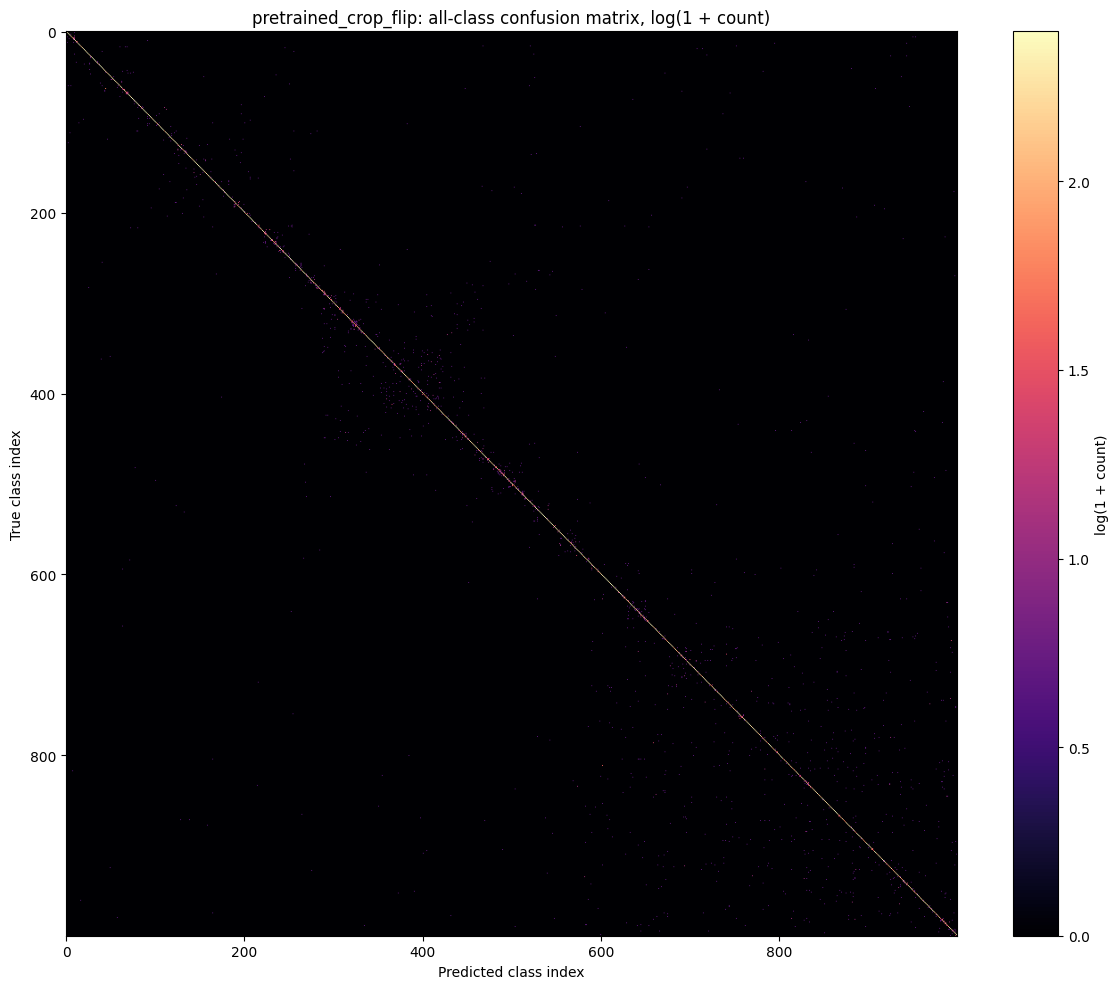

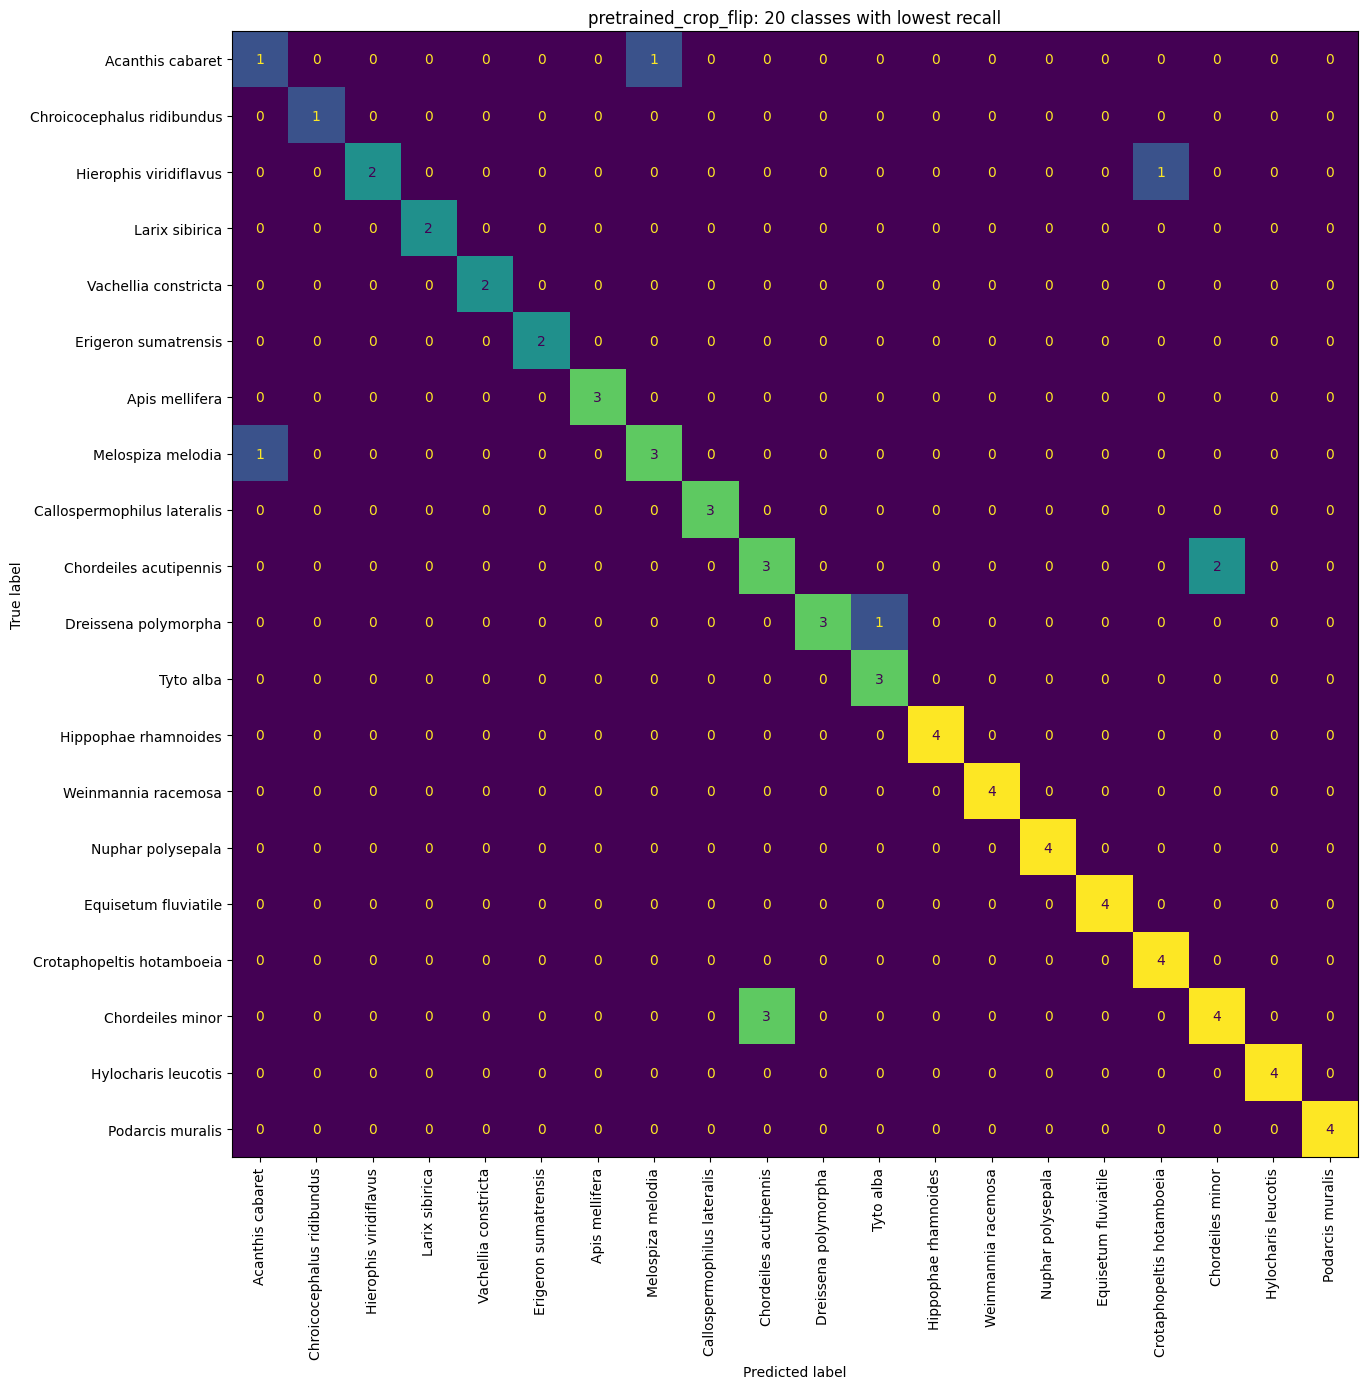

top1_accuracy                             0.792
top5_accuracy                            0.9321
overall_accuracy                          0.792
balanced_accuracy                         0.792
macro_precision                        0.807428
macro_recall                              0.792
macro_f1                               0.790822
experiment                 pretrained_crop_flip
initialisation                      ImageNet-1K
augmentation                          crop_flip
test_images                               10000
test_loss                              0.957376
test_runtime_seconds                    53.3784
test_samples_per_second                 187.342
dtype: object

In [22]:
experiment_name = "pretrained_crop_flip"
test_metrics = evaluate_experiment(experiment_name)
pd.Series(test_metrics)

### f. Evaluate the pre-trained model, with random crop only

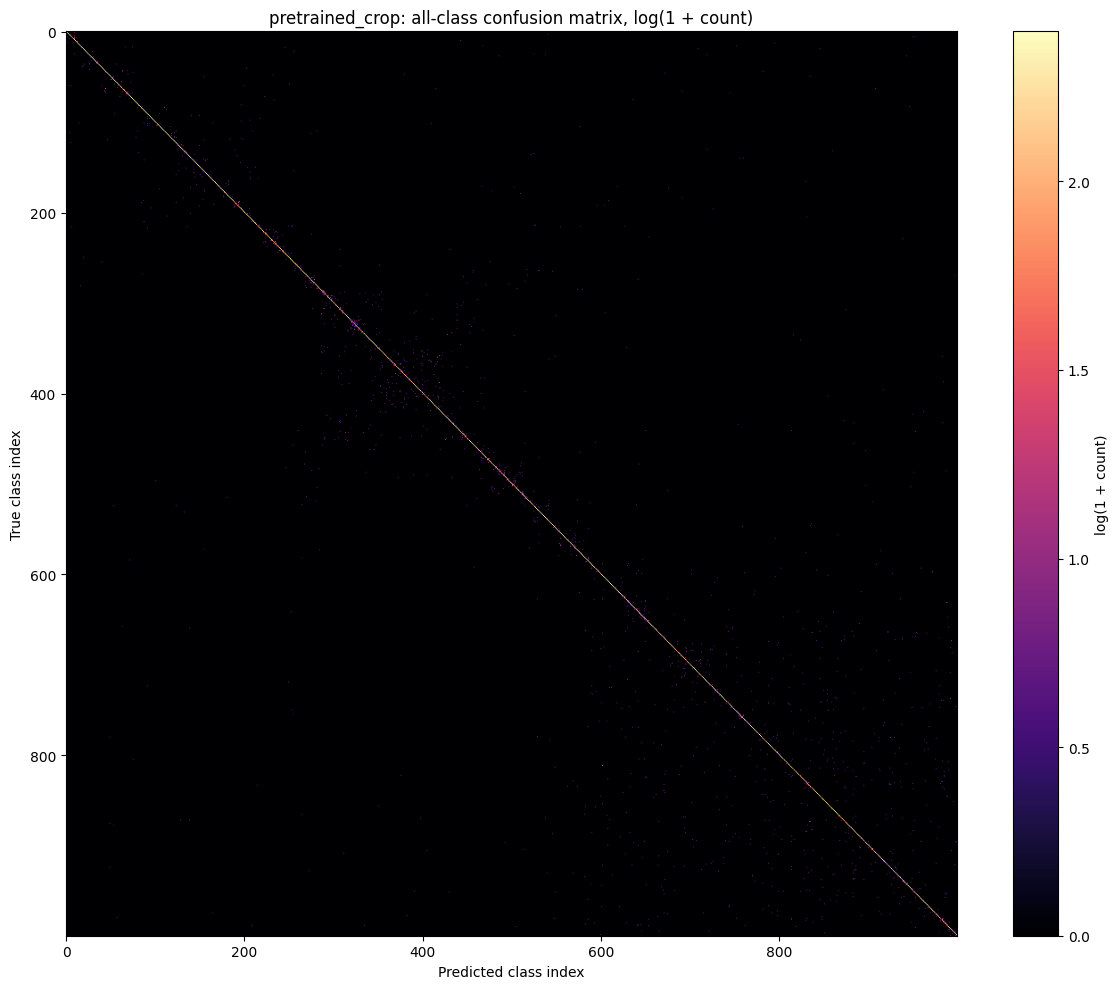

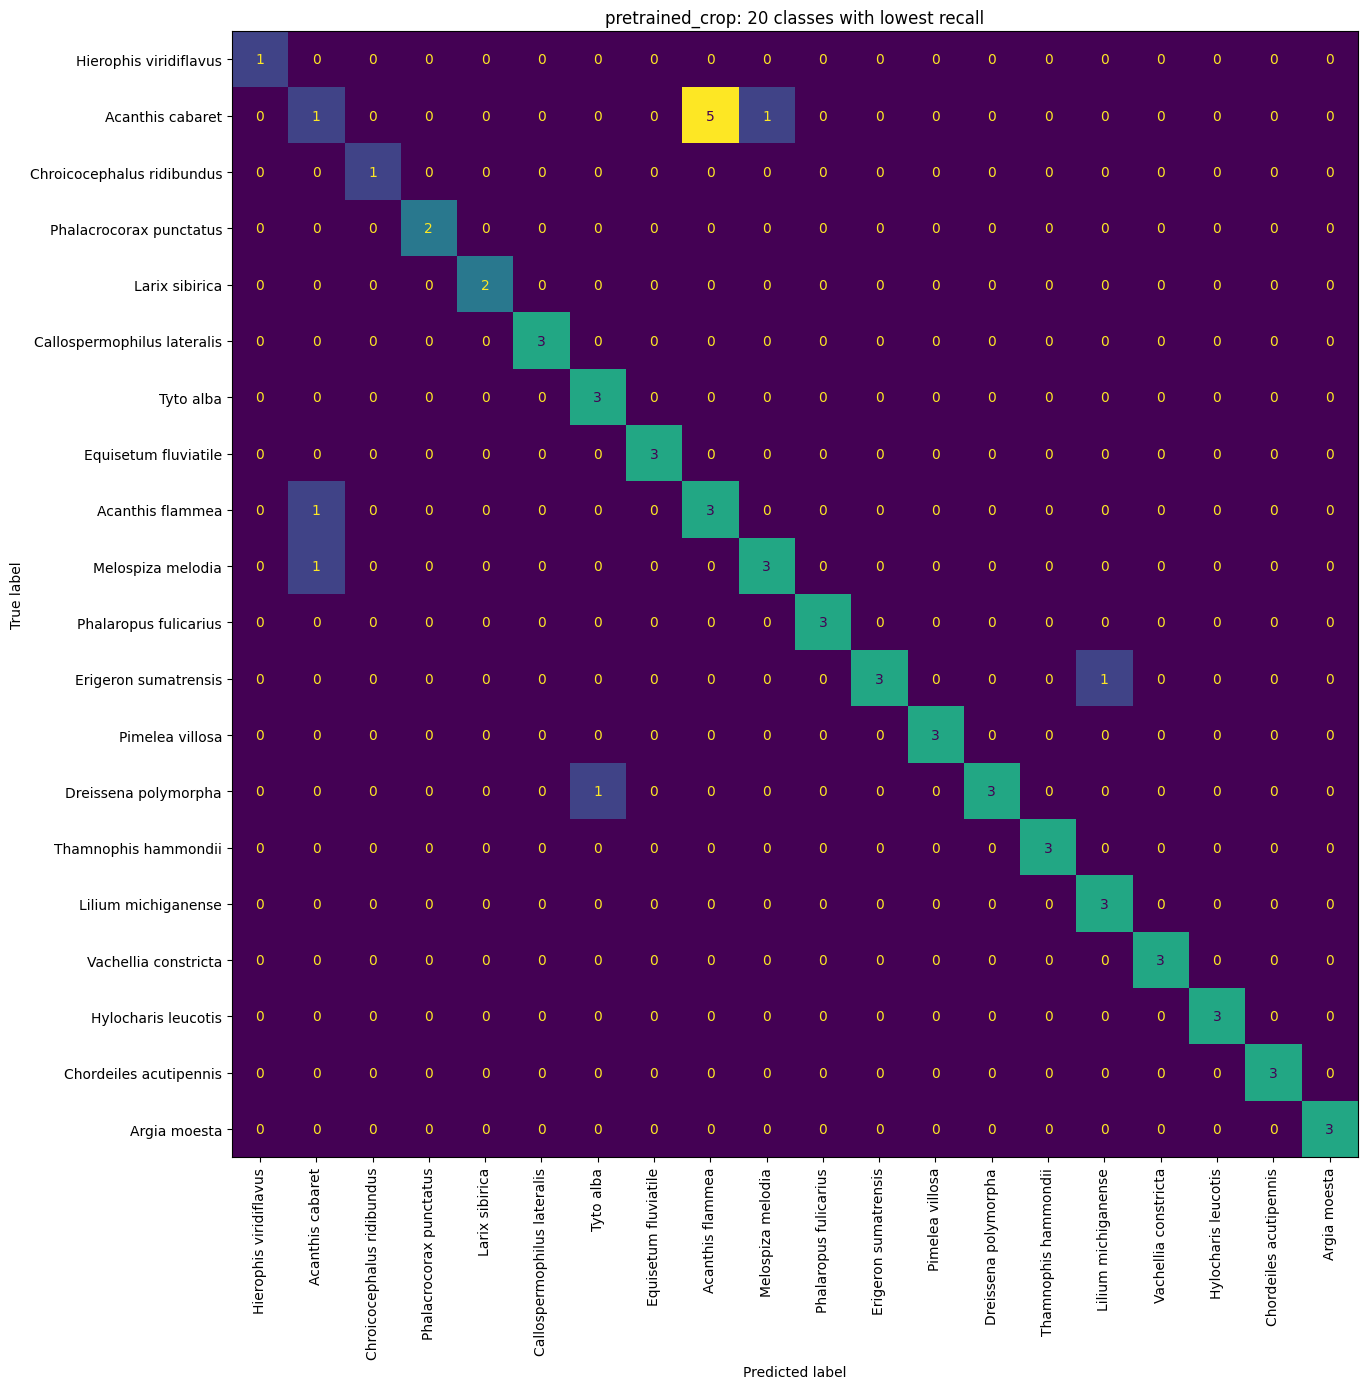

top1_accuracy                       0.7862
top5_accuracy                        0.929
overall_accuracy                    0.7862
balanced_accuracy                   0.7862
macro_precision                   0.801693
macro_recall                        0.7862
macro_f1                          0.784276
experiment                 pretrained_crop
initialisation                 ImageNet-1K
augmentation                          crop
test_images                          10000
test_loss                         0.993557
test_runtime_seconds               53.4432
test_samples_per_second            187.115
dtype: object

In [23]:
experiment_name = "pretrained_crop"
test_metrics = evaluate_experiment(experiment_name)
pd.Series(test_metrics)

## Compare completed experiments
This reads the saved test metrics

In [26]:
# Summarize and Compare All Experiments
metric_files = sorted((OUTPUT_ROOT / "final_models").glob("*/test_result/test_metrics.csv"))
completed_results = []

for metric_file in metric_files:
    result = pd.read_csv(metric_file).iloc[0].to_dict()
    final_dir = metric_file.parent.parent
    with (final_dir / "metadata.json").open("r", encoding="utf-8") as file:
        metadata = json.load(file)
    with (final_dir / "train_metrics.json").open("r", encoding="utf-8") as file:
        train_metrics = json.load(file)
    result["training_runtime_this_call_seconds"] = metadata["training_runtime_this_call_seconds"]
    result["trainer_train_runtime_seconds"] = train_metrics["train_runtime"]
    completed_results.append(result)

# Create a DataFrame to compare all experiments
comparison = pd.DataFrame(completed_results)
comparison_columns = [
    "experiment",
    "initialisation",
    "augmentation",
    "test_loss",
    "top1_accuracy",
    "top5_accuracy",
    "balanced_accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "training_runtime_this_call_seconds",
    "trainer_train_runtime_seconds",
    "test_runtime_seconds",
    "test_samples_per_second",
]
comparison = comparison[comparison_columns].sort_values("macro_f1", ascending=False)
comparison

,experiment,initialisation,augmentation,test_loss,top1_accuracy,top5_accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,training_runtime_this_call_seconds,trainer_train_runtime_seconds,test_runtime_seconds,test_samples_per_second
1,pretrained_crop_flip,ImageNet-1K,crop_flip,0.957376,0.7920,0.9321,0.7920,0.807428,0.7920,0.790822,12039.351157,12039.0750,53.3784,187.342
2,pretrained_full_aug,ImageNet-1K,full,0.958013,0.7917,0.9325,0.7917,0.807553,0.7917,0.790291,12588.350242,12588.3420,54.9983,181.824
0,pretrained_crop,ImageNet-1K,crop,0.993557,0.7862,0.9290,0.7862,0.801693,0.7862,0.784276,11637.410248,11637.1276,53.4432,187.115
3,pretrained_no_aug,ImageNet-1K,none,1.059170,0.7763,0.9226,0.7763,0.790887,0.7763,0.774165,11057.515324,11057.4830,121.9106,82.027
4,scratch_full_aug,random,full,2.581155,0.4852,0.7055,0.4852,0.499816,0.4852,0.480685,19868.009967,19867.2261,53.6942,186.240
5,scratch_no_aug,random,none,3.554922,0.3188,0.5492,0.3188,0.347434,0.3188,0.315597,11694.027108,11692.9534,53.5421,186.769


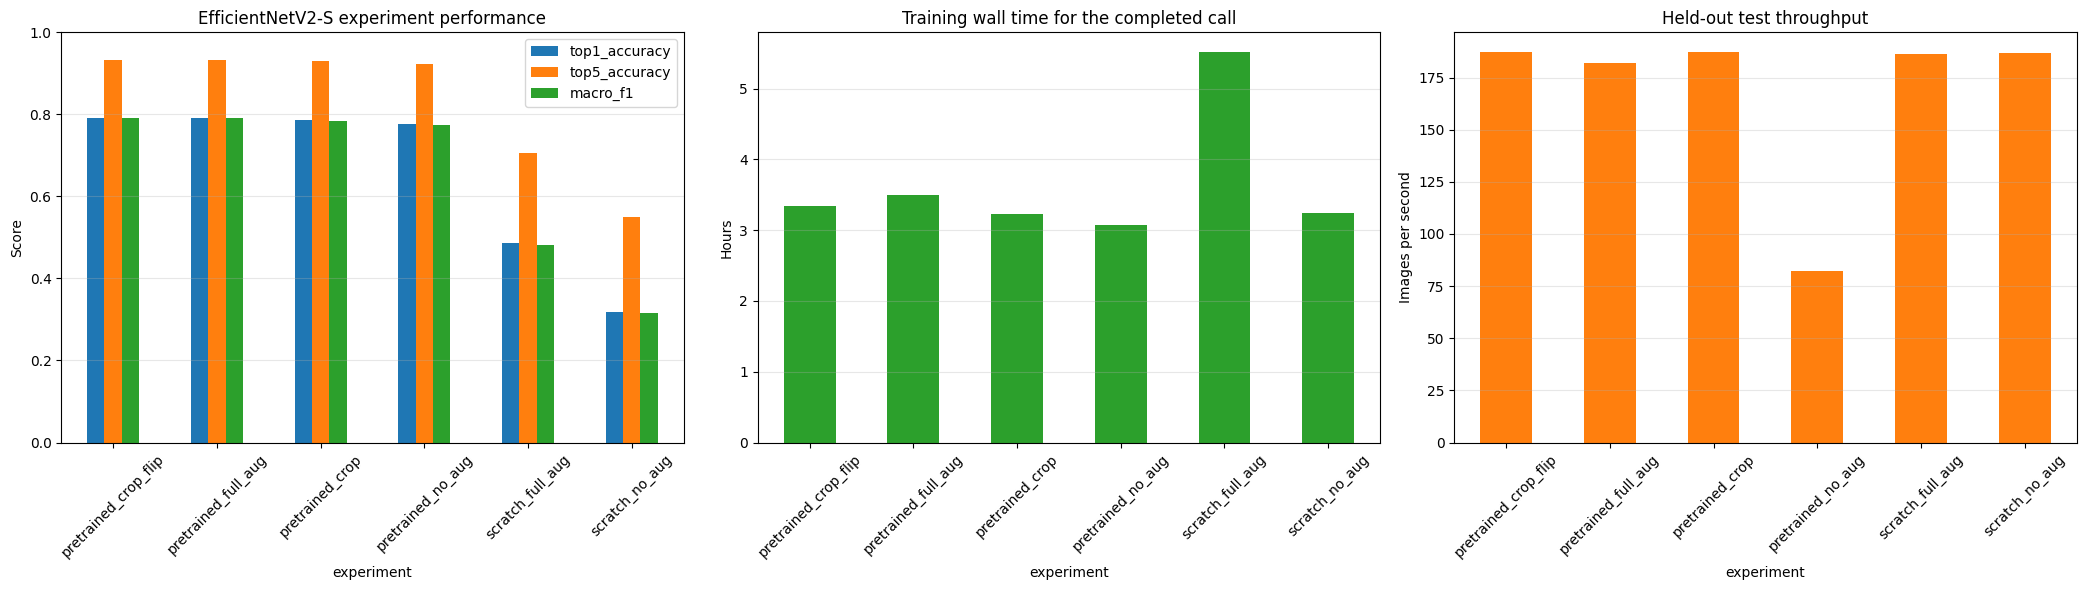

In [27]:
# Visualize the comparison of experiments
plot_data = comparison.set_index("experiment")
plot_data["training_hours_this_call"] = plot_data["training_runtime_this_call_seconds"] / 3600
figure, axes = plt.subplots(1, 3, figsize=(21, 6))

plot_data[["top1_accuracy", "top5_accuracy", "macro_f1"]].plot.bar(ax=axes[0])
axes[0].set(title="EfficientNetV2-S experiment performance", ylabel="Score", ylim=(0, 1))
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y", alpha=0.3)

plot_data["training_hours_this_call"].plot.bar(ax=axes[1], color="tab:green")
axes[1].set(title="Training wall time for the completed call", ylabel="Hours")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", alpha=0.3)

plot_data["test_samples_per_second"].plot.bar(ax=axes[2], color="tab:orange")
axes[2].set(title="Held-out test throughput", ylabel="Images per second")
axes[2].tick_params(axis="x", rotation=45)
axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Example Inference
The same preprocessing used during validation and testing applied.

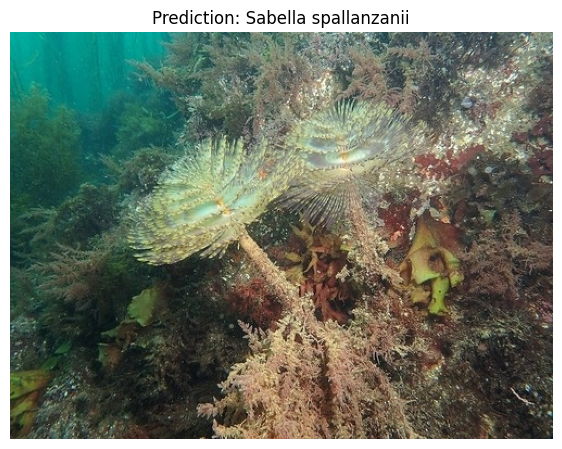

,class_index,species,folder_name,probability
0,0,Sabella spallanzanii,00001_Animalia_Annelida_Polychaeta_Sabellida_S...,0.765013
1,522,Evechinus chloroticus,05210_Animalia_Echinodermata_Echinoidea_Camaro...,0.010357
2,586,Tortula muralis,05758_Plantae_Bryophyta_Bryopsida_Pottiales_Po...,0.007497
3,768,Drosera aberrans,07470_Plantae_Tracheophyta_Magnoliopsida_Caryo...,0.005433
4,990,Telmatoblechnum serrulatum,09920_Plantae_Tracheophyta_Polypodiopsida_Poly...,0.004819


In [28]:
# Example Inference on a Single Image
DEMO_EXPERIMENT = "pretrained_full_aug"
DEMO_IMAGE_PATH = next(TEST_IMAGES_PATH.rglob("*.jpg"))

demo_model = load_trained_model(DEMO_EXPERIMENT)
demo_image = Image.open(DEMO_IMAGE_PATH).convert("RGB")
demo_tensor = EVALUATION_TRANSFORM(demo_image).unsqueeze(0).to(DEVICE)

with torch.inference_mode():
    demo_logits = demo_model(pixel_values=demo_tensor).logits
    demo_probabilities = torch.softmax(demo_logits, dim=1)
    top_probabilities, top_indices = demo_probabilities.topk(5, dim=1)

demo_results = pd.DataFrame({
    "class_index": top_indices[0].cpu().numpy(),
    "species": [scientific_name(CLASS_NAMES[index]) for index in top_indices[0].cpu().numpy()],
    "folder_name": [CLASS_NAMES[index] for index in top_indices[0].cpu().numpy()],
    "probability": top_probabilities[0].cpu().numpy(),
})

plt.figure(figsize=(7, 7))
plt.imshow(demo_image)
plt.title(f"Prediction: {demo_results.iloc[0]['species']}")
plt.axis("off")
plt.show()
display(demo_results)

## Output Structure

    EfficientNetV2_S_outputs/
    ├── class_mapping.csv
    ├── checkpoints/
    │   └── <experiment>/
    │       └── checkpoint-<step>/
    └── final_models/
        └── <experiment>/
            ├── model.safetensors
            ├── training_args.bin
            ├── metadata.json
            ├── train_metrics.json
            ├── trainer_history.csv
            ├── training_curves.png
            └── test_result/
                ├── confusion_matrix_all_classes.png
                ├── confusion_matrix_lowest_recall_20.png
                ├── test_prediction.csv
                └── test_metrics.csv

In [10]:
# Reload class mapping
saved_class_mapping = pd.read_csv(
    OUTPUT_ROOT / "class_mapping.csv",
    dtype={"species_id": str},
)

# Reload test predictions
saved_test_predictions = {}

for experiment_name, config in EXPERIMENTS.items():
    prediction_csv = (
        config["final_dir"]
        / "test_result"
        / "test_prediction.csv"
    )

    saved_test_predictions[experiment_name] = pd.read_csv(
        prediction_csv,
        dtype={
            "prediction_species_id": str,
            "true_species_id": str,
        },
    )

print(
    f"Loaded predictions for "
    f"{len(saved_test_predictions)} experiments."
)

Loaded predictions for 6 experiments.


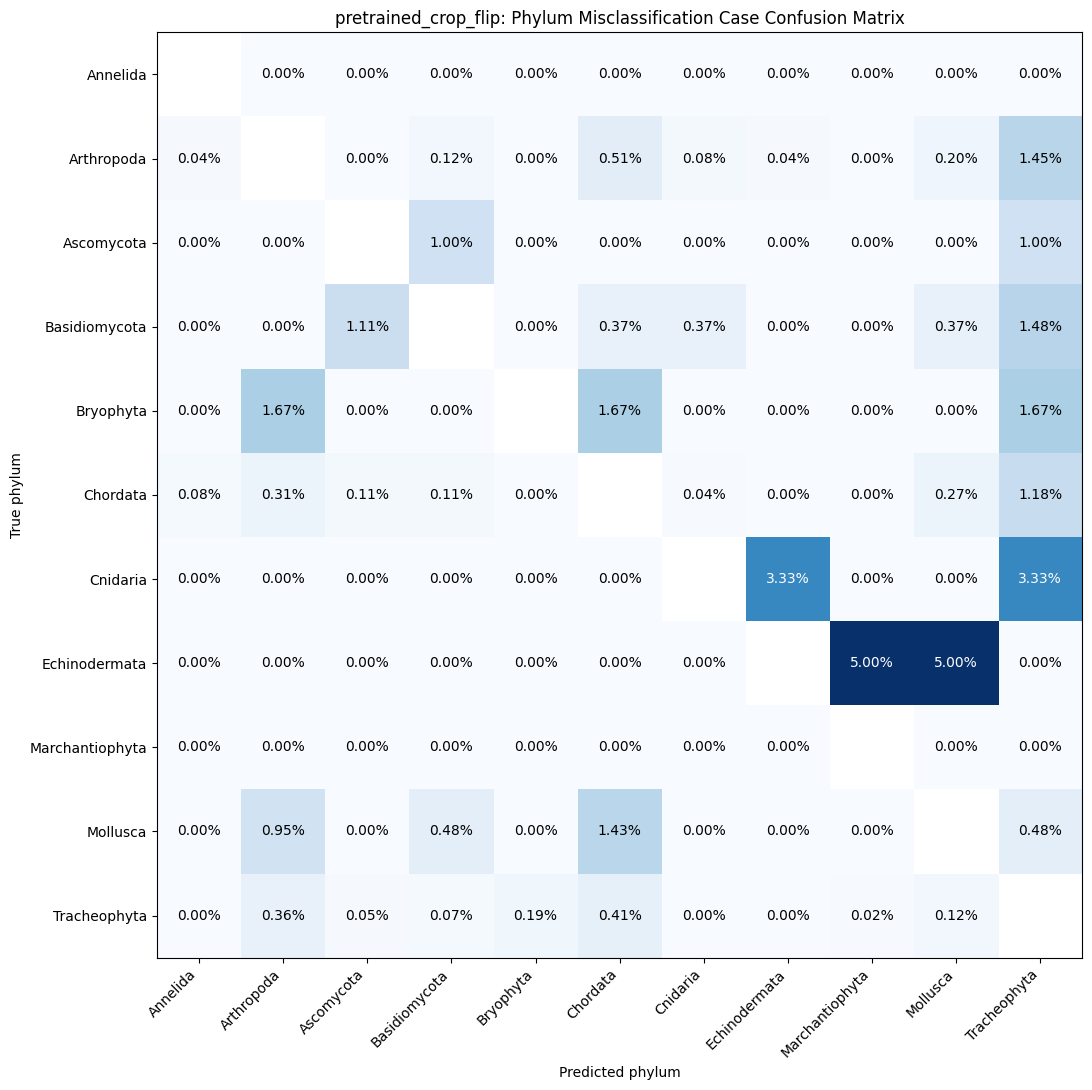

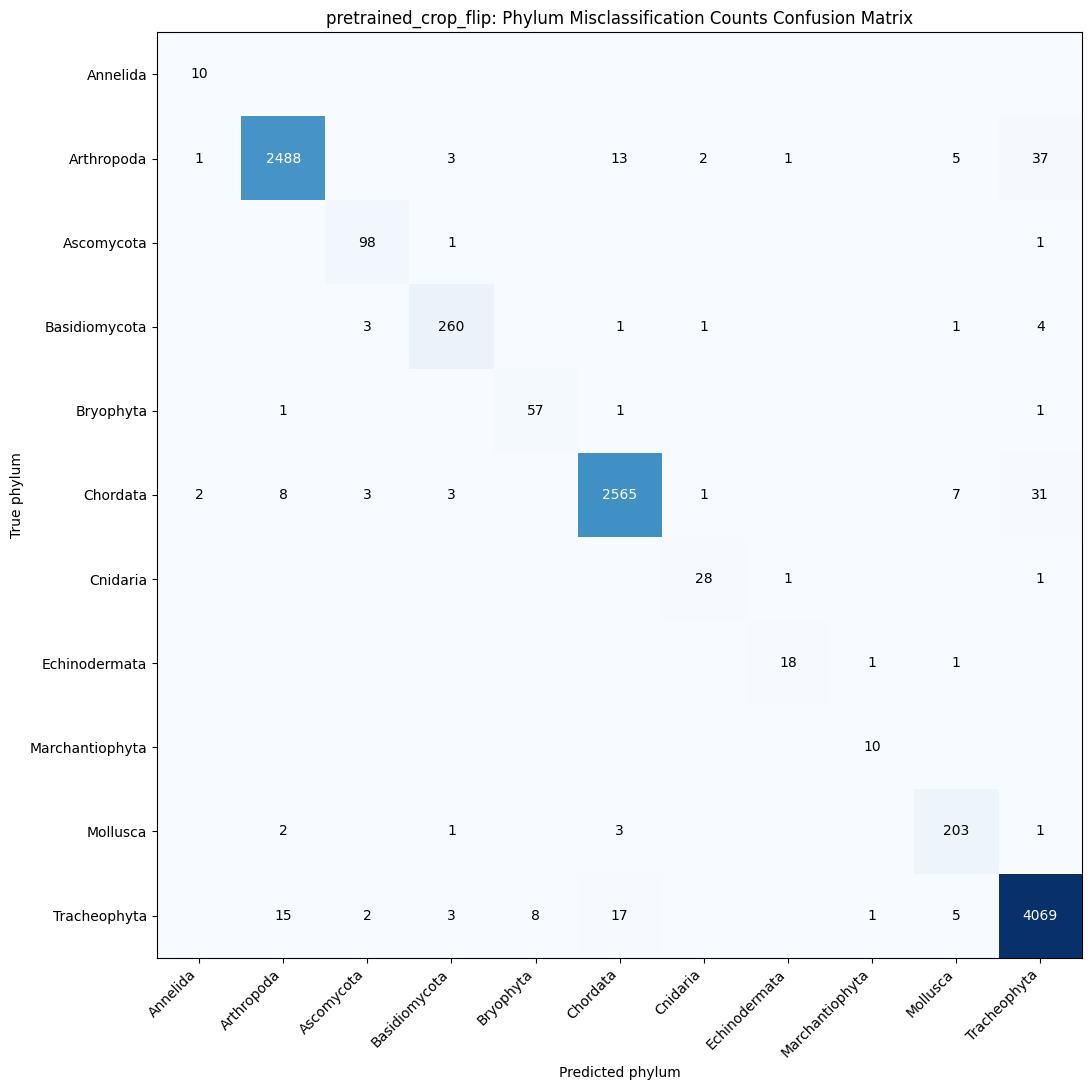

,phylum,number_of_species
0,Annelida,1
1,Arthropoda,255
2,Ascomycota,10
3,Basidiomycota,27
4,Bryophyta,6
5,Chordata,262
6,Cnidaria,3
7,Echinodermata,2
8,Marchantiophyta,1
9,Mollusca,21


In [12]:
experiment_chosen = "pretrained_crop_flip"

predictions = saved_test_predictions[experiment_chosen].copy()
class_mapping = saved_class_mapping.copy()
class_mapping["phylum"] = class_mapping["folder_name"].str.split("_").str[2]

species_to_phylum = class_mapping.set_index("species_id")["phylum"]
predictions["true_phylum"] = predictions["true_species_id"].map(species_to_phylum)
predictions["prediction_phylum"] = predictions["prediction_species_id"].map(species_to_phylum)

phyla = sorted(class_mapping["phylum"].unique())
phylum_counts = pd.crosstab(
    predictions["true_phylum"],
    predictions["prediction_phylum"],
).reindex(index=phyla, columns=phyla, fill_value=0)

phylum_percentages = (
    phylum_counts.div(phylum_counts.sum(axis=1), axis=0) * 100
)

heatmap_values = phylum_percentages.to_numpy().copy()
np.fill_diagonal(heatmap_values, np.nan)
maximum_error = np.nanmax(heatmap_values)
colour_map = plt.cm.Blues.copy()
colour_map.set_bad("white")

figure, axis = plt.subplots(figsize=(13, 11))
axis.imshow(
    heatmap_values,
    cmap=colour_map,
    vmin=0,
    vmax=maximum_error if maximum_error > 0 else 1,
)

axis.set_xticks(np.arange(len(phyla)))
axis.set_yticks(np.arange(len(phyla)))
axis.set_xticklabels(phyla, rotation=45, ha="right")
axis.set_yticklabels(phyla)
axis.set_xlabel("Predicted phylum")
axis.set_ylabel("True phylum")
axis.set_title(f"{experiment_chosen}: Phylum Misclassification Case Confusion Matrix")

for row in range(len(phyla)):
    for column in range(len(phyla)):
        if row == column:
            continue
        value = phylum_percentages.iat[row, column]
        axis.text(
            column,
            row,
            f"{value:.2f}%",
            ha="center",
            va="center",
            color="white" if maximum_error > 0 and value >= maximum_error / 2 else "black",
        )

figure.tight_layout()
plt.show()

count_values = phylum_counts.to_numpy()
maximum_count = count_values.max()

count_figure, count_axis = plt.subplots(figsize=(13, 11))
count_axis.imshow(
    count_values,
    cmap="Blues",
    vmin=0,
    vmax=maximum_count if maximum_count > 0 else 1,
)

count_axis.set_xticks(np.arange(len(phyla)))
count_axis.set_yticks(np.arange(len(phyla)))
count_axis.set_xticklabels(phyla, rotation=45, ha="right")
count_axis.set_yticklabels(phyla)
count_axis.set_xlabel("Predicted phylum")
count_axis.set_ylabel("True phylum")
count_axis.set_title(f"{experiment_chosen}: Phylum Misclassification Counts Confusion Matrix")

for row in range(len(phyla)):
    for column in range(len(phyla)):
        value = phylum_counts.iat[row, column]
        if value == 0:
            continue
        count_axis.text(
            column,
            row,
            f"{value}",
            ha="center",
            va="center",
            color="white" if maximum_count > 0 and value >= maximum_count / 2 else "black",
        )

count_figure.tight_layout()
plt.show()

phylum_species_table = (
    class_mapping
    .groupby("phylum")["species_id"]
    .nunique()
    .reindex(phyla)
    .rename("number_of_species")
    .reset_index()
)
phylum_species_table